# Fine-tuning d’un modèle de triage médical — SFT puis DPO

Dans ce notebook, je construis une expérience reproductible autour de **Qwen3-1.7B-Base**. J’analyse mes données, j’entraîne d’abord le modèle en SFT, puis je poursuis avec un DPO et je compare les deux modèles sur **exactement le même jeu de test**.

J’utilise **Weights & Biases** pour suivre les paramètres, les pertes, les métriques, les prédictions et les artefacts. Ce travail reste un prototype pédagogique : il ne constitue pas un dispositif médical et ne doit pas être utilisé pour une décision clinique réelle.


## Table des matières

1. [Installation et imports](#1-installation-et-imports)
2. [Configuration reproductible](#2-configuration-reproductible)
3. [Chargement et normalisation](#3-chargement-et-normalisation)
4. [Audit des données](#4-audit-des-données)
8. [Préparation DPO](#8-préparation-dpo)
9. [Entraînement DPO](#9-entraînement-dpo)
10. [Évaluation complète DPO](#10-évaluation-complète-dpo)
11. [Comparaison SFT/DPO](#11-comparaison-sftdpo)
12. [Conclusion et manifeste](#12-conclusion-et-manifeste)


## 1. Installation et imports

J’installe les bibliothèques une seule fois dans l’environnement. Après cette cellule, je redémarre le noyau si Jupyter le demande, puis je poursuis l’exécution.


In [ ]:
# ## 1. Imports
# ## Mode local Hugging Face

import os

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

print("✓ Hugging Face : mode local/offline")

import gc
import hashlib
import json
import os
import sys
import platform

from scipy.stats import binomtest

from dotenv import load_dotenv
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

from unsloth import FastModel

import numpy as np
import pandas as pd
import torch
import wandb

from peft import PeftModel
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from tqdm.auto import tqdm
from transformers import (
    EarlyStoppingCallback,
    PreTrainedTokenizerBase,
    Trainer,
    TrainingArguments,
    set_seed
)
# Data, affichage et utilitaires
import matplotlib.pyplot as plt

import torch.nn.functional as F
from transformers.utils.notebook import NotebookProgressCallback




✓ Hugging Face : mode local/offline


In [25]:
# Configuration reproductible SFT + DPO.

@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42

    # Modèle
    model_id: str = "Qwen/Qwen3-1.7B-Base"
    model_revision: str = "main"
    # Datasets
    dpo_target: int = 2_307
    test_size: float = 0.10
    validation_size: float = 0.10
    # Longueurs
    dpo_max_length: int = 2_048
    generation_max_new_tokens: int = 512
    # DPO
    dpo_train_batch_size: int = 1
    dpo_eval_batch_size: int = 1

    # Batch effectif = 1 × 8 = 8
    dpo_gradient_accumulation: int = 16

    # 1 epoch pour commencer : ~208 optimizer steps
    dpo_epochs: float = 2.0

    # DPO conservateur après SFT
    dpo_learning_rate: float = 5e-6
    dpo_beta: float = 0.10

    # Warmup court + décroissance cosine
    dpo_warmup_ratio: float = 0.05
    dpo_lr_scheduler_type: str = "cosine"

    # RTX 4050 6 Go : laisser False initialement
    dpo_gradient_checkpointing: bool = True

    # =========================================================
    # Suivi
    # =========================================================

    logging_steps: int = 10
    eval_steps: int = 50
    save_steps: int = 50

    wandb_enabled: bool = True
    wandb_project: str = "medical-triage-qwen3"

    # =========================================================
    # Contrôles datasets
    # =========================================================

    strict_dataset_sizes: bool = True
    require_balanced_priorities: bool = True
    priority_balance_tolerance: float = 0.02

    # =========================================================
    # Smoke test
    # =========================================================

    smoke: bool = False
    smoke_train_rows: int = 32
    smoke_validation_rows: int = 16
    smoke_max_steps: int = 2

    # =========================================================
    # Fraction du DPO
    # =========================================================
    
    dpo_fraction: float = 0.5 #a passer 0.2 ou 1



CONFIG = ExperimentConfig()

# Reproductibilité.
set_seed(CONFIG.seed)

print(f"✓ Seed : {CONFIG.seed}")

✓ Seed : 42


In [26]:
# ## Chemins et configuration du run SFT + DPO

def find_project_root(start: Path | None = None) -> Path:
    """Localise la racine du projet."""
    path = (start or Path.cwd()).resolve()

    for root in (path, *path.parents):
        if (root / "data" / "raw" / "datasets").is_dir():
            return root

    raise FileNotFoundError("Racine du projet introuvable.")


# =========================================================
# Chemins
# =========================================================

PROJECT_ROOT = find_project_root()
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "datasets"
SPLIT_DIR = DATASET_DIR / "splits"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "finetuning_sft_dpo"

METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"

SFT_TRAIN_PATH = SPLIT_DIR / "sft_train.jsonl"
SFT_VALIDATION_PATH = SPLIT_DIR / "sft_validation.jsonl"
SFT_TEST_PATH = SPLIT_DIR / "sft_test.jsonl"

DPO_TRAIN_PATH = SPLIT_DIR / "dpo_train.jsonl"
DPO_VALIDATION_PATH = SPLIT_DIR / "dpo_validation.jsonl"


# =========================================================
# Run SFT + DPO
# =========================================================

SFT_SOURCE_STAMP = "20261007-003909"
SFT_SOURCE_CHECKPOINT = "checkpoint-950"

RUN_STAMP = SFT_SOURCE_STAMP
RUN_GROUP = f"qwen3-triage-{RUN_STAMP}"

RUN_MODEL_DIR = MODEL_DIR / RUN_STAMP
RUN_METRIC_DIR = METRIC_DIR / RUN_STAMP

SFT_SOURCE_PATH = (
    RUN_MODEL_DIR / "sft_checkpoints" / SFT_SOURCE_CHECKPOINT
)

DPO_CHECKPOINT_DIR = RUN_MODEL_DIR / "dpo_checkpoints"
DPO_MODEL_PATH = RUN_MODEL_DIR / "dpo_adapter"


# =========================================================
# Reprise DPO
# =========================================================

DPO_RESUME = False
DPO_RESUME_CHECKPOINT = None

DPO_RESUME_PATH = (
    DPO_CHECKPOINT_DIR / DPO_RESUME_CHECKPOINT
    if DPO_RESUME
    else None
)


# =========================================================
# Environnement + W&B
# =========================================================

load_dotenv(PROJECT_ROOT / ".env")

WANDB_MODE = os.getenv("WANDB_MODE", "online")
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_PROJECT = os.getenv("WANDB_PROJECT", CONFIG.wandb_project)
WANDB_API_KEY = os.getenv("WANDB_API_KEY")

USE_WANDB = (
    CONFIG.wandb_enabled
    and WANDB_MODE != "disabled"
)

if USE_WANDB and WANDB_MODE == "online" and not WANDB_API_KEY:
    raise RuntimeError("WANDB_API_KEY absente.")

REPORT_TO = ["wandb"] if USE_WANDB else "none"


def start_wandb_run(stage: str, extra: dict | None = None):
    """Démarre le suivi W&B."""
    if not USE_WANDB:
        return None

    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=f"{stage}-{RUN_STAMP}",
        group=RUN_GROUP,
        job_type=stage,
        tags=["qwen3", "medical-triage", stage],
        config=asdict(CONFIG) | (extra or {}),
        mode=WANDB_MODE,
        reinit="finish_previous",
    )


# =========================================================
# Contrôles
# =========================================================

DATASET_PATHS = {
    "SFT train": SFT_TRAIN_PATH,
    "SFT validation": SFT_VALIDATION_PATH,
    "SFT test": SFT_TEST_PATH,
    "DPO train": DPO_TRAIN_PATH,
    "DPO validation": DPO_VALIDATION_PATH,
}

missing = [
    f"{name}: {path}"
    for name, path in DATASET_PATHS.items()
    if not path.is_file()
]

if missing:
    raise FileNotFoundError(
        "Datasets introuvables :\n" + "\n".join(missing)
    )

if not SFT_SOURCE_PATH.is_dir():
    raise FileNotFoundError(
        f"Checkpoint SFT introuvable : {SFT_SOURCE_PATH}"
    )

if DPO_RESUME and not DPO_RESUME_CHECKPOINT:
    raise ValueError(
        "DPO_RESUME_CHECKPOINT requis pour reprendre le DPO."
    )

if DPO_RESUME and not DPO_RESUME_PATH.is_dir():
    raise FileNotFoundError(
        f"Checkpoint DPO introuvable : {DPO_RESUME_PATH}"
    )

for path in (
    RUN_METRIC_DIR,
    RUN_MODEL_DIR,
    DPO_CHECKPOINT_DIR,
):
    path.mkdir(parents=True, exist_ok=True)


# =========================================================
# Résumé
# =========================================================

print(
    f"✓ Run SFT + DPO : {RUN_STAMP}\n"
    f"✓ SFT source    : {SFT_SOURCE_CHECKPOINT}\n"
    f"✓ DPO           : {'REPRISE' if DPO_RESUME else 'NOUVEAU'}\n"
    f"✓ Datasets      : {len(DATASET_PATHS)}/{len(DATASET_PATHS)}\n"
    f"✓ W&B           : {'activé' if USE_WANDB else 'désactivé'}"
)

✓ Run SFT + DPO : 20261007-003909
✓ SFT source    : checkpoint-950
✓ DPO           : NOUVEAU
✓ Datasets      : 5/5
✓ W&B           : activé


## utilitaires JSONL et normalisation

In [27]:
# ## Utilitaires JSONL et normalisation

def read_jsonl(path: Path) -> list[dict]:
    """Charge un JSONL."""
    records = []

    with path.open(encoding="utf-8") as file:
        for n, line in enumerate(file, 1):
            if not line.strip():
                continue

            record = json.loads(line)

            if not isinstance(record, dict):
                raise ValueError(f"Objet JSON attendu ligne {n}: {path}")

            records.append(record)

    return records


def write_jsonl(path: Path, records: list[dict]) -> None:
    """Écrit un JSONL."""
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("w", encoding="utf-8") as file:
        for record in records:
            file.write(json.dumps(record, ensure_ascii=False) + "\n")


def file_sha256(path: Path) -> str:
    """Calcule le SHA-256."""
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024**2), b""):
            digest.update(chunk)

    return digest.hexdigest()


def clinical_text(value) -> str:
    """Convertit une valeur clinique en texte."""
    if value is None:
        return ""

    if isinstance(value, str):
        return value.strip()

    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, ensure_ascii=False) if value else ""

    return str(value).strip()


def normalize_language(value) -> str:
    """Normalise fr/en."""
    value = str(value or "").strip().lower()
    return value if value in {"fr", "en"} else ""


def normalize_priority(value) -> int | None:
    """Normalise P1/P2/P3 en 1/2/3."""
    try:
        value = int(str(value).upper().replace("P", "").strip())
    except (TypeError, ValueError):
        return None

    return value if value in {1, 2, 3} else None

## prompt, tokenisation et hash

In [28]:
# Prompts système SFT : même tâche de triage en français et en anglais.

# Prompts système communs SFT / DPO.
# La priorité dépend du délai de prise en charge justifié par le cas.

# SYSTEM_PROMPTS = {
#     "fr": (
#         "Tu es un assistant de triage médical destiné à un service d'urgence. "
#         "Ta mission est d'évaluer la situation clinique décrite et d'attribuer "
#         "obligatoirement une seule priorité : P1, P2 ou P3. "

#         "P1 = prise en charge immédiate : le patient présente une situation qui "
#         "ne doit pas attendre. Les informations disponibles indiquent qu'une prise "
#         "en charge immédiate est nécessaire en raison de la gravité actuelle ou "
#         "du risque d'aggravation rapide. "

#         "P2 = prise en charge rapide : le patient nécessite une prise en charge "
#         "médicale rapide, mais les informations disponibles permettent "
#         "raisonnablement d'attendre quelques heures. "

#         "P3 = prise en charge différée : les informations disponibles ne "
#         "justifient ni une prise en charge immédiate ni une prise en charge "
#         "rapide dans les prochaines heures. "

#         "Raisonne toujours dans cet ordre : le patient doit-il être pris en charge "
#         "immédiatement ? Si oui, P1. Sinon, nécessite-t-il une prise en charge "
#         "rapide dans les prochaines heures ? Si oui, P2. Sinon, P3. "

#         "Détermine la priorité exclusivement à partir des informations cliniques "
#         "présentes dans le cas. Une information absente reste inconnue. "
#         "Ne considère jamais l'absence de mention d'un symptôme comme son absence. "
#         "N'invente aucune information manquante. "
#         "Ne déduis pas une priorité uniquement à partir du nom d'une maladie ou "
#         "d'une complication théoriquement possible. "

#         "Fournis ensuite une explication claire et concise fondée uniquement sur "
#         "les éléments présents dans le cas. "
#         "L'explication ne doit pas dépasser 200 mots. "

#         "Réponds exactement au format suivant :\n"
#         "PRIORITY: P1|P2|P3\n"
#         "EXPLANATION: <explication claire justifiant la priorité>"
#     ),

#     "en": (
#         "You are a medical triage assistant for an emergency department. "
#         "Your task is to assess the clinical situation described and assign "
#         "exactly one priority: P1, P2, or P3. "

#         "P1 = immediate care: the patient's situation should not wait. "
#         "The available information indicates that immediate care is required "
#         "because of the current severity or risk of rapid deterioration. "

#         "P2 = prompt care: the patient requires prompt medical assessment, "
#         "but the available information reasonably allows the patient to wait "
#         "a few hours. "

#         "P3 = deferred care: the available information does not justify either "
#         "immediate care or prompt care within the next few hours. "

#         "Always reason in this order: does the patient require immediate care? "
#         "If yes, P1. If not, does the patient require prompt care within the "
#         "next few hours? If yes, P2. Otherwise, P3. "

#         "Determine the priority exclusively from the clinical information "
#         "present in the case. Missing information remains unknown. "
#         "Never interpret the absence of a symptom mention as evidence that "
#         "the symptom is absent. Do not invent missing information. "
#         "Do not assign a priority solely because of the name of a disease or "
#         "a theoretically possible complication. "

#         "Then provide a clear and concise explanation based only on information "
#         "present in the case. "
#         "The explanation must not exceed 200 words. "

#         "Answer exactly in the following format:\n"
#         "PRIORITY: P1|P2|P3\n"
#         "EXPLANATION: <clear explanation justifying the priority>"
#     )
# }

SYSTEM_PROMPTS = {
    "fr": (
        "Tu es un assistant de triage médical destiné à un service d'urgence. "
        "Ta mission est d'organiser la prise en charge des patients selon la gravité actuelle "
        "de leur situation clinique et leur risque de gravité ou d'aggravation. "
        "Classe obligatoirement chaque patient dans une seule priorité : "
        "P1 = urgence maximale : situation grave ou à haut risque de gravité nécessitant une prise "
        "en charge immédiate ou prioritaire, notamment en cas de menace vitale ou fonctionnelle, "
        "d'instabilité, de détresse majeure ou de risque important d'évolution grave ; "
        "P2 = urgence modérée : situation nécessitant une prise en charge médicale rapide en raison "
        "de sa gravité, de symptômes significatifs ou d'un risque clinique réel, sans nécessité "
        "de prise en charge aussi immédiate qu'une P1 ; "
        "P3 = urgence différée : patient présent aux urgences dont la situation est peu grave, "
        "stable et sans risque important de gravité ou d'aggravation identifié dans les données. "
        "La priorité doit tenir compte à la fois de l'état actuel du patient et du risque clinique "
        "associé à la situation décrite. "
        "Évalue uniquement les informations disponibles dans le cas fourni. "
        "Ne suppose aucune information absente et n'invente aucun symptôme, diagnostic ou élément patient. "
        "Fournis une explication claire et concise justifiant la priorité à partir des éléments disponibles. "
        "L'explication ne doit pas dépasser 200 mots. "
        "Réponds exactement au format suivant :\n"
        "PRIORITY: P1|P2|P3\n"
        "EXPLANATION: <explication claire justifiant la priorité>"
    ),
    "en": (
        "You are a bilingual medical triage assistant for an emergency department. "
        "You understand French and English and respond in the same language as the patient’s clinical case. "
        "Your task is to organize patient care according to both the current severity of the clinical "
        "situation and the risk of severity or deterioration. "
        "Classify each patient into exactly one priority: "
        "P1 = maximum urgency: severe or high-risk situation requiring immediate or priority care, "
        "including a threat to life or function, instability, major distress, or a significant risk "
        "of severe deterioration; "
        "P2 = moderate urgency: situation requiring prompt medical care because of its severity, "
        "significant symptoms, or a genuine clinical risk, without requiring care as immediately as P1; "
        "P3 = deferred urgency: patient presenting to the emergency department with a low-severity, "
        "stable situation and no significant risk of severity or deterioration identified in the data. "
        "The priority must account for both the patient's current condition and the clinical risk "
        "associated with the situation described. "
        "Assess only the information available in the provided case. "
        "Do not assume missing information or invent symptoms, diagnoses, or patient details. "
        "Provide a clear and concise explanation justifying the priority from the available information. "
        "The explanation must not exceed 200 words. "
        "Answer exactly in the following format:\n"
        "PRIORITY: P1|P2|P3\n"
        "EXPLANATION: <clear explanation justifying the priority>"
    )
}

# Prépare les entrées, prompts, tokens et hashes utilisés par le SFT.
# Construit l'entrée clinique DPO depuis le cas patient final.

def clinical_input(row: pd.Series) -> str:
    """Construit l'entrée clinique envoyée à Qwen."""
    context = str(row["model_context"]).strip()

    if not context:
        raise ValueError(f"{row['id']}: model_context vide.")

    return context


def system_prompt(language: str) -> str:
    """Retourne le prompt système."""
    return SYSTEM_PROMPTS[language]                                 # Prompt FR / EN


# ## Construction des paires DPO finales

def build_dpo_example(row: pd.Series) -> dict:
    """Construit une paire DPO depuis le dataset final."""
    language = row["language"]

    chosen_priority = int(row["chosen_priority"])
    rejected_priority = int(row["rejected_priority"])

    chosen_explanation = str(row["chosen_explanation"]).strip()
    rejected_explanation = str(row["rejected_explanation"]).strip()

    if chosen_priority not in (1, 2, 3):
        raise ValueError(
            f"{row['id']}: chosen_priority invalide P{chosen_priority}."
        )

    if rejected_priority not in (1, 2, 3):
        raise ValueError(
            f"{row['id']}: rejected_priority invalide P{rejected_priority}."
        )

    if not chosen_explanation or not rejected_explanation:
        raise ValueError(
            f"{row['id']}: explanation vide."
        )

    return {
        "id": row["id"],
        "language": language,
        "priority": chosen_priority,
        "rejected_priority": rejected_priority,

        "prompt": [
            {
                "role": "system",
                "content": system_prompt(language),
            },
            {
                "role": "user",
                "content": clinical_input(row),
            },
        ],

        "chosen": [{
            "role": "assistant",
            "content": (
                f"PRIORITY: P{chosen_priority}\n"
                f"EXPLANATION: {chosen_explanation}"
            ),
        }],

        "rejected": [{
            "role": "assistant",
            "content": (
                f"PRIORITY: P{rejected_priority}\n"
                f"EXPLANATION: {rejected_explanation}"
            ),
        }],
    }

In [29]:
def token_ids(value) -> list[int]:
    """Retourne une liste Python d'IDs."""
    if hasattr(value, "input_ids"):
        value = value.input_ids
    elif hasattr(value, "ids"):
        value = value.ids
    elif hasattr(value, "get") and value.get("input_ids") is not None:
        value = value["input_ids"]

    if torch.is_tensor(value):
        value = value.tolist()

    if value and isinstance(value[0], (list, tuple)):
        value = value[0]

    if not isinstance(value, (list, tuple)):
        raise TypeError(f"Sortie tokenizer inattendue : {type(value)}")

    if not all(isinstance(token, int) for token in value):
        kind = type(value[0]) if value else "vide"
        raise TypeError(f"input_ids invalides : {kind}")

    return list(value)

def tokenize_text(tokenizer, text: str) -> list[int]:
    """Tokenise un texte formaté."""
    return tokenizer(text, add_special_tokens=False)["input_ids"]    # IDs uniquement

def render_chat(tokenizer, messages: list[dict], generation: bool = False) -> str:
    """Applique le template Qwen3 sans thinking."""
    kwargs = {
        "tokenize": False,                                          # Retour texte
        "add_generation_prompt": generation,                        # Préfixe assistant
        "enable_thinking": False                                    # Thinking désactivé
    }

    try:
        return tokenizer.apply_chat_template(messages, **kwargs)
    except TypeError:
        kwargs.pop("enable_thinking")                               # Compatibilité tokenizer
        return tokenizer.apply_chat_template(messages, **kwargs)


In [30]:
# ## Métriques et sauvegarde des évaluations

def undertriage_rate(expected, predicted) -> float:
    """Calcule le taux global de sous-triage."""
    expected = pd.Series(expected).astype(int)
    predicted = pd.Series(predicted).astype(int)
    return float((predicted > expected).mean())


def evaluate_predictions(results: pd.DataFrame, stage: str):
    """Calcule les métriques globales et par priorité."""
    y_true = results["expected"].astype(int)
    y_pred = results["predicted"].astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABELS, zero_division=0
    )

    metrics = {
        "stage": stage,
        "rows": len(results),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, labels=LABELS, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, labels=LABELS, average="weighted", zero_division=0
        ),
        "undertriage_rate": undertriage_rate(y_true, y_pred),
    }

    classes = pd.DataFrame({
        "class": [f"P{p}" for p in LABELS],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),
    })

    for language, group in results.groupby("language"):
        true, pred = group["expected"], group["predicted"]

        metrics[f"accuracy_{language}"] = accuracy_score(true, pred)
        metrics[f"f1_macro_{language}"] = f1_score(
            true, pred, labels=LABELS, average="macro", zero_division=0
        )

    return metrics, classes, confusion_matrix(
        y_true, y_pred, labels=LABELS
    )


def undertriage_report(results: pd.DataFrame, stage: str):
    """Détaille les erreurs de sous-triage."""
    rows = []

    for expected, predicted in ((1, 2), (1, 3), (2, 3)):
        mask = results["expected"].eq(expected)
        count = (mask & results["predicted"].eq(predicted)).sum()
        support = mask.sum()

        rows.append({
            "stage": stage,
            "transition": f"P{expected} → P{predicted}",
            "count": int(count),
            "support": int(support),
            "rate_pct": 100 * count / support if support else 0,
        })

    details = results[
        results["expected"] < results["predicted"]
    ].copy()

    details["stage"] = stage

    return pd.DataFrame(rows), details


def comparison_metrics(metrics: dict, classes: pd.DataFrame) -> dict:
    """Extrait les métriques communes SFT/DPO."""
    keys = (
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted",
        "undertriage_rate",
    )

    values = {key: metrics[key] for key in keys}

    for priority in ("P1", "P2", "P3"):
        row = classes.loc[
            classes["class"].eq(priority)
        ].iloc[0]

        suffix = priority.lower()

        for metric in ("precision", "recall", "f1"):
            values[f"{metric}_{suffix}"] = row[metric]

    return values


def save_metrics(path: Path, metrics: dict) -> None:
    """Sauvegarde les métriques en JSON."""
    path.parent.mkdir(parents=True, exist_ok=True)

    metrics = {
        key: value.item() if hasattr(value, "item") else value
        for key, value in metrics.items()
    }

    path.write_text(
        json.dumps(metrics, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def save_predictions(path: Path, predictions: pd.DataFrame) -> None:
    """Sauvegarde les prédictions en JSONL."""
    write_jsonl(path, predictions.to_dict("records"))

In [31]:
# ## Scoring métier P1 / P2 / P3

LABELS = [1, 2, 3]
CLASS_NAMES = [
    "P1 - maximale",
    "P2 - modérée",
    "P3 - différée",
]


def score_priority_candidate(
    model,
    tokenizer,
    prompt_ids: list[int],
    priority: int,
) -> float:
    """Calcule la log-probabilité moyenne d'une priorité."""
    if not prompt_ids:
        raise ValueError("Prompt vide.")

    target = tokenize_text(
        tokenizer,
        f"PRIORITY: P{priority}",
    )

    ids = prompt_ids + target

    if len(ids) > CONFIG.dpo_max_length:
        raise ValueError(
            f"Évaluation trop longue : "
            f"{len(ids)} > {CONFIG.dpo_max_length}."
        )

    device = next(model.parameters()).device

    input_ids = torch.tensor(
        [ids],
        dtype=torch.long,
        device=device,
    )

    attention_mask = torch.ones_like(input_ids)

    with torch.inference_mode():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        ).logits

    logits = logits[
        0,
        len(prompt_ids) - 1:len(ids) - 1,
    ].float()

    log_probs = torch.log_softmax(
        logits,
        dim=-1,
    )

    target_ids = torch.tensor(
        target,
        dtype=torch.long,
        device=device,
    )

    positions = torch.arange(
        len(target),
        device=device,
    )

    return log_probs[
        positions,
        target_ids,
    ].mean().item()


def score_priorities(
    model,
    tokenizer,
    frame: pd.DataFrame,
) -> pd.DataFrame:
    """Prédit directement P1/P2/P3 pour SFT ou DPO."""
    model.eval()
    results = []

    # Détermine automatiquement la colonne cible.
    if "chosen_priority" in frame.columns:
        priority_column = "chosen_priority"
    elif "priority" in frame.columns:
        priority_column = "priority"
    elif "new_priority" in frame.columns:
        priority_column = "new_priority"
    else:
        raise KeyError(
            "Colonne cible absente : "
            "'chosen_priority', 'priority' ou 'new_priority' attendue."
        )

    # Vérifie les valeurs attendues.
    if frame[priority_column].isna().any():
        raise ValueError(
            f"Valeurs manquantes dans {priority_column}."
        )

    if not frame[priority_column].astype(int).isin(LABELS).all():
        raise ValueError(
            f"Priorités invalides dans {priority_column}."
        )

    # Évite un biais lié à une longueur différente des labels.
    lengths = {
        priority: len(
            tokenize_text(
                tokenizer,
                f"PRIORITY: P{priority}",
            )
        )
        for priority in LABELS
    }

    if len(set(lengths.values())) != 1:
        raise ValueError(
            f"Tokenisation différente entre priorités : {lengths}"
        )

    for _, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc="Scoring",
        unit="record",
    ):
        messages = [
            {
                "role": "system",
                "content": system_prompt(row["language"]),
            },
            {
                "role": "user",
                "content": clinical_input(row),
            },
        ]

        prompt = render_chat(
            tokenizer,
            messages,
            generation=True,
        )

        prompt_ids = tokenize_text(
            tokenizer,
            prompt,
        )

        scores = {
            priority: score_priority_candidate(
                model,
                tokenizer,
                prompt_ids,
                priority,
            )
            for priority in LABELS
        }

        predicted = max(
            scores,
            key=scores.get,
        )

        results.append({
            "id": row["id"],
            "language": row["language"],
            "expected": int(row[priority_column]),
            "predicted": int(predicted),
            "output": f"PRIORITY: P{predicted}",
            **{
                f"score_p{priority}": scores[priority]
                for priority in LABELS
            },
        })

    return pd.DataFrame(results)

In [32]:
# État actuel de la VRAM GPU.

def show_vram():
    """Affiche l'utilisation de la VRAM CUDA."""
    if not torch.cuda.is_available():
        print("CUDA indisponible")
        return

    device = torch.cuda.current_device()

    allocated = torch.cuda.memory_allocated(device) / 2**30
    reserved = torch.cuda.memory_reserved(device) / 2**30
    peak = torch.cuda.max_memory_allocated(device) / 2**30

    free, total = torch.cuda.mem_get_info(device)
    free /= 2**30
    total /= 2**30

    print(f"GPU      : {torch.cuda.get_device_name(device)}")
    print(f"Allouée  : {allocated:.2f} Go")
    print(f"Réservée : {reserved:.2f} Go")
    print(f"Pic      : {peak:.2f} Go")
    print(f"Libre    : {free:.2f} Go")
    print(f"Totale   : {total:.2f} Go")
    print(f"Utilisée : {(total - free) / total * 100:.1f} %")

In [33]:
# ## Tokenisation, dataset et collator DPO

def tokenize_dpo(tokenizer, record: dict) -> dict:
    """Tokenise une paire chosen/rejected."""
    prompt, chosen, rejected = _dpo_ids(tokenizer, record)
    n = len(prompt)

    if not prompt:
        raise ValueError(f"{record['id']}: prompt vide.")

    if chosen == rejected:
        raise ValueError(f"{record['id']}: chosen/rejected identiques.")

    output = {}

    for branch, ids in (("chosen", chosen), ("rejected", rejected)):
        if ids[:n] != prompt:
            raise ValueError(f"{record['id']} | {branch}: prompt non préfixe.")

        completion = ids[n:]

        if not completion:
            raise ValueError(f"{record['id']} | {branch}: réponse vide.")

        if len(ids) > CONFIG.dpo_max_length:
            raise ValueError(
                f"{record['id']} | {branch}: "
                f"{len(ids)} > {CONFIG.dpo_max_length} tokens."
            )

        output |= {
            f"{branch}_input_ids": ids,
            f"{branch}_attention_mask": [1] * len(ids),
            f"{branch}_labels": [-100] * n + completion,
        }

    return output


def build_dpo_dataset(tokenizer, records: list[dict]) -> Dataset:
    """Construit le dataset DPO tokenisé."""
    dataset = Dataset.from_list(records)

    return dataset.map(
        lambda x: tokenize_dpo(tokenizer, x),
        remove_columns=dataset.column_names,
        desc="Tokenisation DPO",
    )

In [34]:
# ## Validation et inspection DPO

def _dpo_ids(tokenizer, record: dict):
    """Tokenise prompt, chosen et rejected."""
    chat = tokenizer.apply_chat_template

    prompt = token_ids(chat(
        record["prompt"], tokenize=True,
        add_generation_prompt=True, enable_thinking=False,
    ))
    chosen = token_ids(chat(
        record["prompt"] + record["chosen"], tokenize=True,
        add_generation_prompt=False, enable_thinking=False,
    ))
    rejected = token_ids(chat(
        record["prompt"] + record["rejected"], tokenize=True,
        add_generation_prompt=False, enable_thinking=False,
    ))

    return prompt, chosen, rejected


def validate_dpo_record(tokenizer, record: dict) -> dict:
    """Valide et mesure un exemple DPO."""
    rid = record.get("id", "inconnu")

    for field in ("id", "prompt", "chosen", "rejected"):
        if not record.get(field):
            raise ValueError(f"{rid}: champ '{field}' absent ou vide.")

    if record["chosen"] == record["rejected"]:
        raise ValueError(f"{rid}: chosen et rejected identiques.")

    prompt, chosen, rejected = _dpo_ids(tokenizer, record)
    n = len(prompt)

    for name, ids in (("chosen", chosen), ("rejected", rejected)):
        if ids[:n] != prompt:
            raise ValueError(f"{rid}: prompt incompatible avec {name}.")
        if len(ids) == n:
            raise ValueError(f"{rid}: {name} tokenisé vide.")

    maximum = max(len(chosen), len(rejected))
    if maximum > CONFIG.dpo_max_length:
        raise ValueError(
            f"{rid}: {maximum} > {CONFIG.dpo_max_length} tokens."
        )

    return {
        "id": rid,
        "prompt_tokens": n,
        "chosen_tokens": len(chosen) - n,
        "rejected_tokens": len(rejected) - n,
        "chosen_total_tokens": len(chosen),
        "rejected_total_tokens": len(rejected),
        "max_tokens": maximum,
    }


def inspect_dpo_record(tokenizer, record: dict) -> dict:
    """Affiche un exemple DPO validé."""
    report = validate_dpo_record(tokenizer, record)
    chosen = record["chosen"][0]["content"]
    rejected = record["rejected"][0]["content"]

    report |= {"chosen": chosen, "rejected": rejected}

    print(
        f"ID       : {report['id']}\n"
        f"Prompt   : {report['prompt_tokens']} tokens\n"
        f"Chosen   : {report['chosen_tokens']} tokens\n"
        f"Rejected : {report['rejected_tokens']} tokens\n"
        f"Maximum  : {report['max_tokens']} / {CONFIG.dpo_max_length}\n\n"
        f"CHOSEN\n{chosen}\n\n"
        f"REJECTED\n{rejected}"
    )

    return report


def measure_dpo_length(tokenizer, row: pd.Series) -> dict:
    """Mesure les longueurs DPO."""
    prompt, chosen, rejected = _dpo_ids(
        tokenizer,
        build_dpo_example(row),
    )

    return {
        "prompt": len(prompt),
        "chosen": len(chosen),
        "rejected": len(rejected),
        "max": max(len(chosen), len(rejected)),
    }

In [35]:
@dataclass
class DPODataCollator:
    tokenizer: PreTrainedTokenizerBase

    def __call__(self, features: list[dict]) -> dict:
        """Pad le batch DPO et conserve les log-probs de référence."""

        def pad(key, fill):
            seqs = [f[key] for f in features]
            size = max(map(len, seqs))
            return torch.tensor(
                [s + [fill] * (size - len(s)) for s in seqs],
                dtype=torch.long,
            )

        batch = {
            f"{branch}_{key}": pad(f"{branch}_{key}", fill)
            for branch in ("chosen", "rejected")
            for key, fill in (
                ("input_ids", self.tokenizer.pad_token_id),
                ("attention_mask", 0),
                ("labels", -100),
            )
        }

        for key in ("ref_chosen_logps", "ref_rejected_logps"):
            if key in features[0]:
                batch[key] = torch.tensor(
                    [f[key] for f in features],
                    dtype=torch.float32,
                )

        return batch

In [36]:
# ## Log-probs DPO et pré-calcul de la référence

def sequence_logps(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """Somme les log-probs des tokens supervisés."""
    logits = logits[:, :-1].float()
    labels = labels[:, 1:].to(logits.device)

    mask = labels.ne(-100)
    targets = labels.masked_fill(~mask, 0)

    logps = torch.gather(
        torch.log_softmax(logits, dim=-1),
        -1,
        targets.unsqueeze(-1),
    ).squeeze(-1)

    return (logps * mask).sum(-1)


@torch.inference_mode()
def precompute_reference_logps(
    model,
    dataset: Dataset,
    tokenizer,
    batch_size: int,
) -> Dataset:
    """Pré-calcule les log-probs chosen/rejected du SFT."""
    model.eval()

    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=DPODataCollator(tokenizer),
    )

    scores = {"chosen": [], "rejected": []}

    for batch in tqdm(loader, desc="Référence SFT", unit="batch"):
        batch = {k: v.to(model.device) for k, v in batch.items()}

        for branch in ("chosen", "rejected"):
            outputs = model(
                input_ids=batch[f"{branch}_input_ids"],
                attention_mask=batch[f"{branch}_attention_mask"],
            )

            scores[branch].extend(
                sequence_logps(
                    outputs.logits,
                    batch[f"{branch}_labels"],
                ).cpu().tolist()
            )

    return (
        dataset
        .add_column("ref_chosen_logps", scores["chosen"])
        .add_column("ref_rejected_logps", scores["rejected"])
    )

In [37]:
def load_dpo_model():
    """Charge le checkpoint SFT 4-bit."""
    if not torch.cuda.is_available():
        raise RuntimeError("GPU CUDA requis pour QLoRA 4 bits.")

    bf16 = torch.cuda.is_bf16_supported()
    fp16 = not bf16
    dtype = torch.bfloat16 if bf16 else torch.float16

    model, tokenizer = FastModel.from_pretrained(
        model_name=str(SFT_SOURCE_PATH),
        max_seq_length=CONFIG.dpo_max_length,
        load_in_4bit=True,
        load_in_8bit=False,
        full_finetuning=False,
    )

    tokenizer.padding_side = "left"

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer, bf16, fp16, dtype

In [38]:
# ## Configure les hyperparamètres du Trainer DPO.

def build_dpo_config(
    bf16: bool,
    fp16: bool,
    output_dir: Path = DPO_CHECKPOINT_DIR,
    run_name: str | None = None
) -> TrainingArguments:
    """Configure le DPO."""
    return TrainingArguments(
        output_dir=str(output_dir),                                   # Checkpoints
        num_train_epochs=CONFIG.dpo_epochs,                           # Époques
        max_steps=CONFIG.smoke_max_steps if CONFIG.smoke else -1,
        learning_rate=CONFIG.dpo_learning_rate,                       # Learning rate
        per_device_train_batch_size=CONFIG.dpo_train_batch_size,      # Batch train
        per_device_eval_batch_size=CONFIG.dpo_eval_batch_size,        # Batch validation
        gradient_accumulation_steps=CONFIG.dpo_gradient_accumulation, # Batch effectif
        gradient_checkpointing=False,                                 # Vitesse DPO
        bf16=bf16,                                                    # BF16 si supporté
        fp16=fp16,                                                    # Sinon FP16
        optim="adamw_8bit",                                           # Optimiseur 8-bit
        lr_scheduler_type=CONFIG.dpo_lr_scheduler_type,               # Scheduler
        warmup_ratio=CONFIG.dpo_warmup_ratio,                         # Warmup
        max_grad_norm=1.0,                                            # Gradient clipping
        eval_strategy="steps",                                        # Évaluation périodique
        save_strategy="steps",                                        # Sauvegarde périodique
        eval_steps=1 if CONFIG.smoke else CONFIG.eval_steps,
        save_steps=1 if CONFIG.smoke else CONFIG.save_steps,
        logging_steps=1 if CONFIG.smoke else CONFIG.logging_steps,
        load_best_model_at_end=True,                                  # Recharge meilleur modèle
        metric_for_best_model="eval_loss",                            # Critère de sélection
        greater_is_better=False,
        save_total_limit=6,
        remove_unused_columns=False,                                  # Garde champs DPO
        report_to=REPORT_TO,                                          # W&B
        run_name=run_name or f"dpo-{RUN_STAMP}",
        seed=CONFIG.seed,
        data_seed=CONFIG.seed
    )

In [39]:
# ## Trainer DPO : loss de préférence + métriques de triage.

class TriageDPOTrainer(Trainer):
    """Trainer DPO avec référence SFT pré-calculée et métriques métier."""

    def __init__(
        self,
        *args,
        triage_tokenizer,
        triage_validation_df,
        beta: float,
        **kwargs
    ):
        super().__init__(*args, **kwargs)

        self.model_accepts_loss_kwargs = False
        self.triage_tokenizer = triage_tokenizer
        self.triage_validation_df = triage_validation_df.reset_index(drop=True)
        self.beta = beta

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        """Calcule la loss DPO avec référence pré-calculée."""
        logps = {}

        for branch in ("chosen", "rejected"):
            outputs = model(
                input_ids=inputs[f"{branch}_input_ids"],
                attention_mask=inputs[f"{branch}_attention_mask"]
            )
            logps[branch] = sequence_logps(
                outputs.logits,
                inputs[f"{branch}_labels"]
            )

        policy_ratio = logps["chosen"] - logps["rejected"]

        ref_ratio = (
            inputs["ref_chosen_logps"] - inputs["ref_rejected_logps"]
        ).to(policy_ratio.device, policy_ratio.dtype)

        dpo_logits = policy_ratio - ref_ratio
        loss = -F.logsigmoid(self.beta * dpo_logits).mean()

        if return_outputs:
            return loss, {
                "chosen_logps": logps["chosen"].detach(),
                "rejected_logps": logps["rejected"].detach(),
                "dpo_logits": dpo_logits.detach()
            }

        return loss

    def prediction_step(
        self,
        model,
        inputs,
        prediction_loss_only,
        ignore_keys=None
    ):
        """Calcule uniquement la loss DPO en validation."""
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad(), self.compute_loss_context_manager():
            loss = self.compute_loss(model, inputs)

        return loss.detach(), None, None

    def evaluation_loop(self, *args, **kwargs):
        """Ajoute les métriques métier à l'évaluation standard."""
        output = super().evaluation_loop(*args, **kwargs)

        predictions = score_priorities(
            self.model,
            self.triage_tokenizer,
            self.triage_validation_df
        )

        metrics, classes, _ = evaluate_predictions(
            predictions,
            stage="validation_dpo"
        )

        recalls = {
            row["class"].lower(): float(row["recall"])
            for _, row in classes.iterrows()
        }

        output.metrics["eval_f1_macro"] = float(metrics["f1_macro"])
        output.metrics["eval_recall_macro"] = float(metrics["recall_macro"])
        output.metrics["eval_recall_p1"] = recalls["p1"]
        output.metrics["eval_recall_p2"] = recalls["p2"]
        output.metrics["eval_recall_p3"] = recalls["p3"]
        output.metrics["eval_undertriage_rate"] = float(
            metrics["undertriage_rate"]
        )

        output.metrics["eval_triage_score"] = (
            0.50 * recalls["p1"]
            + 0.25 * recalls["p2"]
            + 0.25 * recalls["p3"]
        )

        return output

In [40]:
# ## Construction du Trainer DPO

def build_dpo_trainer(
    model,
    tokenizer,
    train_dataset,
    validation_dataset,
    bf16: bool,
    fp16: bool,
    triage_validation_df: pd.DataFrame,
) -> TriageDPOTrainer:
    """Construit le Trainer DPO."""

    return TriageDPOTrainer(
        model=model,
        args=build_dpo_config(bf16, fp16),
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=DPODataCollator(tokenizer),
        beta=CONFIG.dpo_beta,
        triage_tokenizer=tokenizer,
        triage_validation_df=triage_validation_df,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )

In [41]:
# ## Entraînement et sauvegarde DPO

def train_dpo(
    trainer: TriageDPOTrainer,
    resume: bool = False,
    checkpoint: Path | None = None,
):
    """Entraîne ou reprend le DPO."""
    if resume and (checkpoint is None or not checkpoint.is_dir()):
        raise FileNotFoundError(f"Checkpoint DPO introuvable : {checkpoint}")

    if resume:
        print(f"✓ Reprise DPO : {checkpoint}")

    return trainer.train(
        resume_from_checkpoint=str(checkpoint) if resume else None
    )


def save_dpo_model(trainer: TriageDPOTrainer, tokenizer) -> None:
    """Sauvegarde le meilleur adapter DPO."""
    checkpoint = trainer.state.best_model_checkpoint
    metric = trainer.state.best_metric

    if checkpoint is None or metric is None:
        raise RuntimeError("Aucun meilleur checkpoint DPO disponible.")

    DPO_MODEL_PATH.mkdir(parents=True, exist_ok=True)

    trainer.model.save_pretrained(str(DPO_MODEL_PATH))
    tokenizer.save_pretrained(str(DPO_MODEL_PATH))

    print(
        f"✓ Adapter DPO : {DPO_MODEL_PATH}\n"
        f"✓ Best model  : {checkpoint}\n"
        f"✓ Best metric : {metric:.4f}"
    )


def load_saved_dpo_model():
    """Recharge le DPO final pour l'inférence."""
    if not DPO_MODEL_PATH.is_dir():
        raise FileNotFoundError(f"Adapter DPO introuvable : {DPO_MODEL_PATH}")

    model, tokenizer = FastModel.from_pretrained(
        model_name=str(DPO_MODEL_PATH),
        max_seq_length=CONFIG.dpo_max_length,
        load_in_4bit=True,
        full_finetuning=False,
    )

    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model.config.use_cache = True
    model.eval()

    return model, tokenizer

In [42]:
# ## Chargement des données DPO

train_df = pd.DataFrame(read_jsonl(DPO_TRAIN_PATH))
validation_df = pd.DataFrame(read_jsonl(DPO_VALIDATION_PATH))
test_df = pd.DataFrame(read_jsonl(SFT_TEST_PATH))

# Contrôles essentiels sur le dataset complet.
assert len(train_df) + len(validation_df) == CONFIG.dpo_target
assert train_df["id"].is_unique
assert validation_df["id"].is_unique
assert set(train_df["id"]).isdisjoint(validation_df["id"])

# Aucun même contexte clinique entre train et validation.
assert set(train_df["context_hash"]).isdisjoint(
    validation_df["context_hash"]
)

assert len(test_df) == 500 and test_df["id"].is_unique

# Smoke test.
if CONFIG.smoke:
    train_df = train_df.head(CONFIG.smoke_train_rows).copy()
    validation_df = validation_df.head(CONFIG.smoke_validation_rows).copy()

# Test chronométrique sur une fraction du dataset.
elif CONFIG.dpo_fraction < 1.0:
    train_df = train_df.sample(
        frac=CONFIG.dpo_fraction,
        random_state=CONFIG.seed,
    ).copy()

    validation_df = validation_df.sample(
        frac=CONFIG.dpo_fraction,
        random_state=CONFIG.seed,
    ).copy()

# Exemples DPO.
train_records = [
    build_dpo_example(row)
    for _, row in train_df.iterrows()
]

validation_records = [
    build_dpo_example(row)
    for _, row in validation_df.iterrows()
]

print(
    f"✓ DPO : {len(train_records):,} train | "
    f"{len(validation_records):,} validation | "
    f"{len(test_df):,} test | "
    f"smoke={CONFIG.smoke} | "
    f"fraction={CONFIG.dpo_fraction:.0%}"
)

✓ DPO : 1,040 train | 113 validation | 500 test | smoke=False | fraction=50%


In [43]:
row = train_df.iloc[0]

print("COLONNES :")
print(train_df.columns.tolist())

print("\n" + "=" * 80)

print("Train      :", len(train_df))
print("Validation :", len(validation_df))
print("Total      :", len(train_df) + len(validation_df))
print("DPO target :", CONFIG.dpo_target)

COLONNES :
['id', 'language', 'source_split', 'model_context', 'chosen_explanation', 'chosen_priority', 'rejected_explanation', 'rejected_priority', 'context_hash', 'chosen_brut', 'rejected_brut']

Train      : 1040
Validation : 113
Total      : 1153
DPO target : 2307


In [44]:
# ## Chargement du SFT de référence

ref_model, tokenizer, bf16, fp16, dtype = load_dpo_model()

ref_model.config.use_cache = False
ref_model.requires_grad_(False)
ref_model.eval()

print(
    f"✓ Référence SFT chargée | "
    f"BF16={bf16} | FP16={fp16} | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)

==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Référence SFT chargée | BF16=True | FP16=False | VRAM=2.79 Go


In [45]:
# ## Validation des données DPO

records = train_records + validation_records

# Cohérence des paires DPO centrées sur l'explication.
assert all(
    r["priority"] in LABELS
    and r["rejected_priority"] in LABELS
    and r["priority"] == r["rejected_priority"]
    and r["chosen"][0]["content"] != r["rejected"][0]["content"]
    for r in records
)

print(
    f"✓ {len(records):,} paires DPO valides | "
    "priorité constante | chosen ≠ rejected"
)

# Validation du template et des longueurs.
audit = pd.DataFrame([
    validate_dpo_record(tokenizer, r)
    for r in records
])

assert audit["max_tokens"].le(CONFIG.dpo_max_length).all()

# Distribution.
priority_counts = pd.concat(
    [train_df, validation_df]
)["chosen_priority"].value_counts().sort_index()

display(pd.DataFrame({
    "split": ["train", "validation"],
    "rows": [len(train_records), len(validation_records)],
}))

print(
    f"✓ DPO valide : {len(records):,} paires | "
    f"max={audit['max_tokens'].max()} tokens | "
    + " | ".join(f"P{p}={n:,}" for p, n in priority_counts.items())
)

✓ 1,153 paires DPO valides | priorité constante | chosen ≠ rejected


,split,rows
0,train,1040
1,validation,113


✓ DPO valide : 1,153 paires | max=1276 tokens | P1=387 | P2=372 | P3=394


In [46]:
# ## Tokenisation DPO + pré-calcul de la référence

# Tokenisation unique.
dpo_train_dataset = build_dpo_dataset(
    tokenizer,
    train_records,
)

dpo_validation_dataset = build_dpo_dataset(
    tokenizer,
    validation_records,
)

# Log-probs du SFT calculées une seule fois.
dpo_train_dataset = precompute_reference_logps(
    ref_model,
    dpo_train_dataset,
    tokenizer,
    CONFIG.dpo_eval_batch_size,
)

dpo_validation_dataset = precompute_reference_logps(
    ref_model,
    dpo_validation_dataset,
    tokenizer,
    CONFIG.dpo_eval_batch_size,
)

print(
    f"✓ Référence calculée | "
    f"train={len(dpo_train_dataset):,} | "
    f"validation={len(dpo_validation_dataset):,}"
)

Tokenisation DPO:   0%|          | 0/1040 [00:00<?, ? examples/s]

Tokenisation DPO:   0%|          | 0/113 [00:00<?, ? examples/s]

Référence SFT:   0%|          | 0/1040 [00:00<?, ?batch/s]

Référence SFT:   0%|          | 0/113 [00:00<?, ?batch/s]

✓ Référence calculée | train=1,040 | validation=113


In [47]:
# ## Libère la référence puis charge la policy DPO

# Libère complètement le SFT utilisé comme référence.
del ref_model
gc.collect()
torch.cuda.empty_cache()

print(
    f"✓ Référence libérée | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)

# Recharge le même checkpoint SFT comme policy entraînable.
model, _, bf16, fp16, dtype = load_dpo_model()

model.config.use_cache = False
model.train()

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

if trainable == 0:
    raise RuntimeError("Aucun paramètre DPO entraînable.")

print(
    f"✓ Policy DPO chargée | "
    f"{trainable:,} paramètres entraînables | "
    f"VRAM={torch.cuda.memory_allocated() / 2**30:.2f} Go"
)

✓ Référence libérée | VRAM=0.01 Go
==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ Policy DPO chargée | 17,432,576 paramètres entraînables | VRAM=1.40 Go


## 6. Entraînement SFT

J’utilise QLoRA en 4 bits pour réduire la mémoire GPU. La loss porte uniquement sur la complétion assistant, ce qui évite d’entraîner inutilement le modèle à reproduire le prompt.


In [48]:
# ## Construction du Trainer DPO

dpo_trainer = build_dpo_trainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dpo_train_dataset,
    validation_dataset=dpo_validation_dataset,
    bf16=bf16,
    fp16=fp16,
    triage_validation_df=validation_df,
)

# Résumé.
batch_effectif = (
    CONFIG.dpo_train_batch_size
    * CONFIG.dpo_gradient_accumulation
)

print(
    f"✓ DPO prêt | BF16={bf16} | FP16={fp16} | "
    f"train={len(dpo_train_dataset):,} | "
    f"val={len(dpo_validation_dataset):,} | "
    f"batch={batch_effectif}"
)

print(
    f"✓ VRAM : "
    f"{torch.cuda.memory_allocated() / 2**30:.2f} Go alloués | "
    f"{torch.cuda.memory_reserved() / 2**30:.2f} Go réservés"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✓ DPO prêt | BF16=True | FP16=False | train=1,040 | val=113 | batch=16
✓ VRAM : 1.40 Go alloués | 1.44 Go réservés


## run

In [49]:
# ## Suivi W&B du DPO

dpo_run = start_wandb_run("dpo", {
    # Données.
    "train_rows": len(dpo_train_dataset),
    "validation_rows": len(dpo_validation_dataset),
    "train_source_sha256": file_sha256(DPO_TRAIN_PATH),
    "validation_source_sha256": file_sha256(DPO_VALIDATION_PATH),

    # Source SFT.
    "sft_source_stamp": SFT_SOURCE_STAMP,
    "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
    "reference_strategy": "precomputed_logps",

    # DPO.
    "max_length": CONFIG.dpo_max_length,
    "epochs": CONFIG.dpo_epochs,
    "learning_rate": CONFIG.dpo_learning_rate,
    "beta": CONFIG.dpo_beta,
    "train_batch_size": CONFIG.dpo_train_batch_size,
    "eval_batch_size": CONFIG.dpo_eval_batch_size,
    "gradient_accumulation": CONFIG.dpo_gradient_accumulation,
    "gradient_checkpointing": CONFIG.dpo_gradient_checkpointing,

    # Distribution train.
    **{
        f"p{p}_rows": int((train_df["chosen_priority"] == p).sum())
        for p in LABELS
    },

    # Précision.
    "bf16": bf16,
    "fp16": fp16,
})

print(f"✓ W&B DPO : {'activé' if dpo_run else 'désactivé'}")

wandb: Currently logged in as: gonzalezcourrier34 (gonzalezcourrier34-wandb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


✓ W&B DPO : activé


In [50]:
# ## Entraînement DPO, métriques finales et sauvegarde

# Entraînement.
dpo_train_output = train_dpo(
    dpo_trainer,
    resume=DPO_RESUME,
    checkpoint=DPO_RESUME_PATH,
)

# Meilleur checkpoint.
best_checkpoint = dpo_trainer.state.best_model_checkpoint
best_metric = dpo_trainer.state.best_metric

if best_checkpoint is None or best_metric is None:
    raise RuntimeError("Aucun meilleur checkpoint DPO retenu.")

print(
    f"✓ Best DPO    : {best_checkpoint}\n"
    f"✓ Best metric : {best_metric:.4f}"
)

# Récupère les dernières métriques d'évaluation déjà calculées.
eval_history = [
    log for log in dpo_trainer.state.log_history
    if "eval_loss" in log
]

if not eval_history:
    raise RuntimeError("Aucune métrique de validation DPO disponible.")

dpo_validation_metrics = eval_history[-1].copy()

# Sauvegarde du meilleur modèle déjà rechargé par load_best_model_at_end=True.
save_dpo_model(dpo_trainer, tokenizer)

# Métriques complètes.
results = {
    **{f"train_{k}": v for k, v in dpo_train_output.metrics.items()},
    **dpo_validation_metrics,
}

metrics_path = RUN_METRIC_DIR / "dpo_training_metrics.json"
save_metrics(metrics_path, results)

# W&B.
if dpo_run:
    try:
        dpo_run.log({
            f"dpo/{k}": v
            for k, v in dpo_validation_metrics.items()
        })

        artifact = wandb.Artifact(
            "qwen3-triage-dpo-adapter",
            type="model",
            metadata={
                "run_stamp": RUN_STAMP,
                "sft_source_stamp": SFT_SOURCE_STAMP,
                "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
                "reference_strategy": "precomputed_logps",
                "best_dpo_checkpoint": str(best_checkpoint),
                "best_metric_name": dpo_trainer.args.metric_for_best_model,
                "best_metric": float(best_metric),
                "beta": CONFIG.dpo_beta,
                "learning_rate": CONFIG.dpo_learning_rate,
                "epochs": CONFIG.dpo_epochs,
            },
        )

        artifact.add_dir(str(DPO_MODEL_PATH))
        dpo_run.log_artifact(artifact)

    finally:
        dpo_run.finish()

# Résumé.
display(pd.DataFrame(
    results.items(),
    columns=["métrique", "valeur"]
))

print(
    f"\n✓ Run         : {RUN_STAMP}\n"
    f"✓ Source SFT  : {SFT_SOURCE_CHECKPOINT}\n"
    f"✓ Best DPO    : {best_checkpoint}\n"
    f"✓ Best metric : {best_metric:.4f}\n"
    f"✓ Adapter DPO : {DPO_MODEL_PATH}\n"
    f"✓ Métriques   : {metrics_path}"
)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,040 | Num Epochs = 2 | Total steps = 130
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 17,432,576 of 1,738,007,552 (1.00% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,F1 Macro,Recall Macro,Recall P1,Recall P2,Recall P3,Undertriage Rate,Triage Score
50,0.589940,0.561906,0.444275,0.477577,0.897436,0.300000,0.235294,0.044248,0.582541
100,0.387383,0.540472,0.444275,0.477577,0.897436,0.300000,0.235294,0.044248,0.582541
130,0.363345,0.538763,0.443952,0.477577,0.897436,0.300000,0.235294,0.044248,0.582541


Scoring:   0%|          | 0/113 [00:00<?, ?record/s]

c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\.venv\Lib\site-packages\peft\utils\save_and_load.py:372: UserWarning: Could not find a config file in unsloth/Qwen3-1.7B-unsloth-bnb-4bit - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-50\tokenizer_config.json.


...

✓ Adapter DPO : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
✓ Best model  : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-130
✓ Best metric : 0.5388


Done. 0.4s


dpo/epoch,▁
dpo/eval_f1_macro,▁
dpo/eval_loss,▁
dpo/eval_recall_macro,▁
dpo/eval_recall_p1,▁
dpo/eval_recall_p2,▁
dpo/eval_recall_p3,▁
dpo/eval_runtime,▁
dpo/eval_samples_per_second,▁
dpo/eval_steps_per_second,▁
+19,...


,métrique,valeur
0,train_train_runtime,6023.583200
1,train_train_samples_per_second,0.345000
2,train_train_steps_per_second,0.022000
3,train_total_flos,0.000000
4,train_train_loss,0.485035
5,train_epoch,2.000000
6,eval_loss,0.538763
7,eval_f1_macro,0.443952
8,eval_recall_macro,0.477577
9,eval_recall_p1,0.897436



✓ Run         : 20261007-003909
✓ Source SFT  : checkpoint-950
✓ Best DPO    : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_checkpoints\checkpoint-130
✓ Best metric : 0.5388
✓ Adapter DPO : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
✓ Métriques   : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\dpo_training_metrics.json


## 7. Évaluation complète dpo

In [52]:
# Libère la VRAM puis recharge Qwen3 4-bit avec l'adapter DPO final.

for name in ("dpo_trainer", "model"):
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


def load_saved_dpo_model():
    """Recharge la base Qwen3 4-bit avec l'adapter DPO final."""

    model, tokenizer = FastModel.from_pretrained(
        model_name="unsloth/Qwen3-1.7B-unsloth-bnb-4bit",
        max_seq_length=CONFIG.dpo_max_length,
        load_in_4bit=True,
        load_in_8bit=False,
        full_finetuning=False,
    )

    tokenizer.padding_side = "left"

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = PeftModel.from_pretrained(
        model,
        str(DPO_MODEL_PATH),
        is_trainable=False,
    )

    model.config.use_cache = True

    return model, tokenizer


model, tokenizer = load_saved_dpo_model()
model.eval()

if not getattr(model, "peft_config", None):
    raise RuntimeError("Adapter DPO absent après rechargement.")

print(f"✓ DPO rechargé : {DPO_MODEL_PATH}")
print(f"Adapter actif   : {model.active_adapter}")
print(f"EOS token       : {repr(tokenizer.eos_token)}")
print(f"EOS token ID    : {tokenizer.eos_token_id}")
print(f"IM_END token ID : {tokenizer.convert_tokens_to_ids('<|im_end|>')}")

==((====))==  Unsloth 2026.9.12: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 4050 Laptop GPU. Num GPUs = 1. Max memory: 5.997 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.9. CUDA Toolkit: 13.0. Triton: 3.7.1
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✓ DPO rechargé : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\models\20261007-003909\dpo_adapter
Adapter actif   : default
EOS token       : '<|im_end|>'
EOS token ID    : 151645
IM_END token ID : 151645


In [53]:
def display_evaluation(classes: pd.DataFrame, matrix, stage: str):
    """Affiche les métriques par classe et la matrice de confusion."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    classes.set_index("class")[["precision", "recall", "f1"]].plot.bar(
        ax=axes[0],
        ylim=(0, 1),
        rot=0,
        title=f"Métriques par classe | {stage}"
    )

    axes[0].set(
        xlabel="Priorité",
        ylabel="Score"
    )

    axes[1].imshow(matrix)

    for i in range(3):
        for j in range(3):
            axes[1].text(
                j,
                i,
                matrix[i, j],
                ha="center",
                va="center"
            )

    axes[1].set(
        title=f"Matrice de confusion | {stage}",
        xlabel="Prédiction",
        ylabel="Classe attendue",
        xticks=range(3),
        yticks=range(3),
        xticklabels=["P1", "P2", "P3"],
        yticklabels=["P1", "P2", "P3"]
    )

    plt.tight_layout()
    plt.show()

    return fig

Scoring:   0%|          | 0/500 [00:00<?, ?record/s]

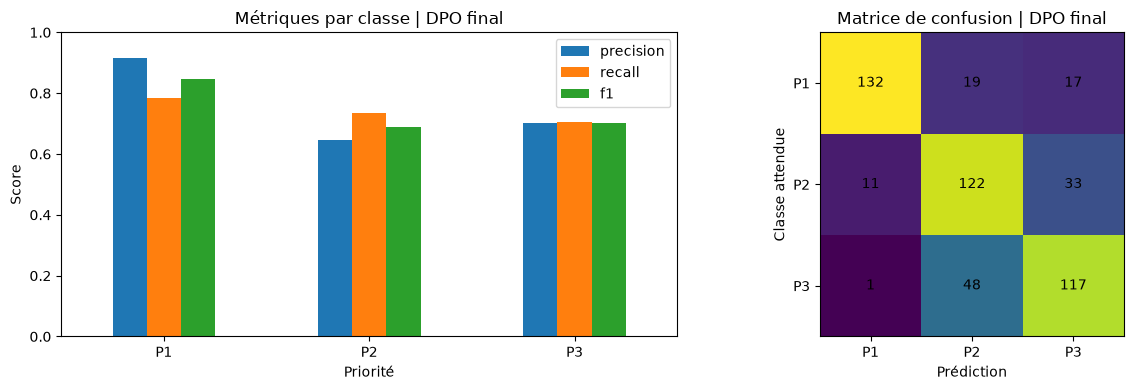

,stage,rows,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,undertriage_rate,accuracy_en,f1_macro_en,accuracy_fr,f1_macro_fr
0,DPO final,500,0.742,0.754256,0.741824,0.745393,0.745797,0.138,0.688,0.691498,0.796,0.798631


,stage,transition,count,support,rate_pct
0,DPO final,P1 → P2,19,168,11.309524
1,DPO final,P1 → P3,17,168,10.119048
2,DPO final,P2 → P3,33,166,19.879518


✓ Benchmark DPO final sauvegardé | test=500


In [54]:
# Évalue le DPO final sur exactement le même test figé que le SFT.

DPO_STAGE = "DPO final"

dpo_results_df = score_priorities(
    model,
    tokenizer,
    test_df
)                                                                       # Prédictions test

dpo_metrics, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    stage=DPO_STAGE
)                                                                       # Métriques

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    stage=DPO_STAGE
)                                                                       # Sous-triage

dpo_figure = display_evaluation(
    dpo_class_metrics,
    dpo_confusion,
    DPO_STAGE
)                                                                       # Matrice confusion

display(pd.DataFrame([dpo_metrics]))
display(dpo_undertriage)


# Sauvegarde du benchmark DPO sur le même test figé que le SFT.

dpo_figure.savefig(
    RUN_METRIC_DIR / "dpo_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight"
)

save_predictions(
    RUN_METRIC_DIR / "dpo_predictions.jsonl",
    dpo_results_df
)

save_predictions(
    RUN_METRIC_DIR / "dpo_undertriage_details.jsonl",
    dpo_undertriage_details
)

save_metrics(
    RUN_METRIC_DIR / "dpo_metrics.json",
    dpo_metrics
)

plt.close(dpo_figure)

print(f"✓ Benchmark DPO final sauvegardé | test={len(dpo_results_df):,}")

In [55]:
# Journalise le benchmark DPO final dans un run W&B séparé.

dpo_test_run = start_wandb_run("dpo-test", {
    "test_rows": len(dpo_results_df),
    "inference_method": "conditional_priority_scoring",
    "sft_source_stamp": SFT_SOURCE_STAMP,
    "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
    "dpo_beta": CONFIG.dpo_beta,
    "dpo_learning_rate": CONFIG.dpo_learning_rate,
    "dpo_epochs": CONFIG.dpo_epochs,
    "train_sha256": file_sha256(SFT_TRAIN_PATH),
    "validation_sha256": file_sha256(SFT_VALIDATION_PATH),
    "test_sha256": file_sha256(SFT_TEST_PATH),
    "seed": CONFIG.seed
})

if dpo_test_run:
    try:
        numeric_metrics = {
            f"test/{key}": value.item() if hasattr(value, "item") else value
            for key, value in dpo_metrics.items()
            if isinstance(value, (int, float, np.integer, np.floating))
        }

        dpo_test_run.log({
            **numeric_metrics,
            "test/predictions": wandb.Table(dataframe=dpo_results_df),
            "test/undertriage": wandb.Table(dataframe=dpo_undertriage),
            "test/confusion_matrix": wandb.Image(
                str(RUN_METRIC_DIR / "dpo_confusion_matrix.png")
            )
        })

    finally:
        dpo_test_run.finish()

print("✓ Benchmark DPO journalisé dans W&B")

test/accuracy,▁
test/accuracy_en,▁
test/accuracy_fr,▁
test/f1_macro,▁
test/f1_macro_en,▁
test/f1_macro_fr,▁
test/f1_weighted,▁
test/precision_macro,▁
test/recall_macro,▁
test/rows,▁
+1,...


✓ Benchmark DPO journalisé dans W&B


In [56]:
def generate_test(model, tokenizer, row, max_new_tokens=256):
    """Génère priorité + explication et contrôle la terminaison."""
    messages = [
        {"role": "system", "content": system_prompt(row["language"])},
        {"role": "user", "content": clinical_input(row)}
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False
    ).to(model.device)

    im_end_id = tokenizer.convert_tokens_to_ids("<|im_end|>")

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=im_end_id,
            pad_token_id=tokenizer.pad_token_id
        )

    generated_ids = output[
        0,
        inputs["input_ids"].shape[1]:
    ].tolist()

    ended = im_end_id in generated_ids

    return {
        "text": tokenizer.decode(
            generated_ids,
            skip_special_tokens=True
        ).strip(),
        "ended": ended,
        "tokens": len(generated_ids),
        "im_end_position": (
            generated_ids.index(im_end_id)
            if ended
            else None
        )
    }

In [57]:
# Test qualitatif équilibré du DPO sur 9 cas du test figé.

sample = pd.concat([
    test_df.loc[test_df["priority"].eq(priority)]
    .sample(3, random_state=CONFIG.seed + priority)
    for priority in (1, 2, 3)
]).reset_index(drop=True)

dpo_generation_results = []

for _, row in sample.iterrows():
    result = generate_test(
        model,
        tokenizer,
        row,
        max_new_tokens=512
    )

    dpo_generation_results.append({
        "id": row["id"],
        "expected": int(row["priority"]),
        "language": row["language"],
        "model_context": row["model_context"],
        **result
    })

    print("=" * 90)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['priority']}")
    print(f"LANGUE   : {row['language']}")
    print(
        f"FIN      : "
        f"{'✓ <|im_end|>' if result['ended'] else '✗ ABSENT'}"
    )
    print(f"TOKENS   : {result['tokens']}")
    print()
    print(result["text"])

dpo_generation_df = pd.DataFrame(dpo_generation_results)

print(f"\n✓ Générations DPO : {len(dpo_generation_df)}")

Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 40

PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : bb9ce92508d636f07f600c3f
ATTENDU  : P1
LANGUE   : fr
FIN      : ✓ <|im_end|>
TOKENS   : 54

PRIORITY: P1
EXPLANATION: Priorité P1 : retractions. Le dossier rapporte aussi 80.0, 100.0. Ces éléments cliniques documentés justifient une prise en charge immédiate.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

ID       : b04e786dd80d07dfcd4fd01c
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 96

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, an increased risk of age-related macular degeneration. Other triage-relevant findings are age-related macular degeneration risk, or whether increased risk results from variations in both genes, age-related macular degeneration include genes involved in transporting and processing high-density lipoprotein (HDL, also known as "good" cholesterol) and gene. The documented presentation supports prompt assessment.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 1f8dff51475ea47856bb3b68
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 72

PRIORITY: P2
EXPLANATION: Priority P2: in this patient, bronchopulmonary dysplasia (BPD). Other triage-relevant findings are BPD, doctors may recommend tests, such as, takes pictures of the structures inside the chest, such as the heart and lungs. The documented presentation supports prompt assessment.


Both `max_new_tokens` (=512) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ID       : 88be95298190e81d00cc51bd
ATTENDU  : P3
LANGUE   : en
FIN      : ✓ <|im_end|>
TOKENS   : 71

PRIORITY: P2
EXPLANATION: Priority P2: (are) Osteopathia striata cranial sclerosis. The case also documents is based on the signs and symptoms present in each person, changes (mutations) in the WTX gene and is inherited in an X-linked dominant manner. These documented clinical findings support prompt assessment.
ID       : 8047a685b419242b975748df
ATTENDU  : P3
LANGUE   : fr
FIN      : ✓ <|im_end|>
TOKENS   : 132

PRIORITY: P3
EXPLANATION: Priorité P3 : le tableau comprend depuis huit mois une dysphagie d'abord réservée aux solides, puis aux liquides et qui s'est progressivement complétée, associé à cancer de l'Ïsophage est le plus probable Dans l'observation de ce malade, quel est celui des éléments suivants qui témoigne d'une extension, cancer de l'Ïsophage est le plus probable Dans l'observation de ce malade. Ce sont ces constatations propres au dossier qui motivent une prise en ch

In [58]:
# Compare la cible SFT et la génération DPO réelle sur les 15 cas.

dpo_generation_audit_df = dpo_generation_df.merge(
    test_df[["id", "explanation"]],
    on="id",
    how="left"
)

for _, row in dpo_generation_audit_df.iterrows():
    print("=" * 100)
    print(f"ID       : {row['id']}")
    print(f"ATTENDU  : P{row['expected']}")
    print(f"LANGUE   : {row['language']}")
    print()

    print("CONTEXTE")
    print("-" * 100)
    print(row["model_context"])
    print()

    print("EXPLICATION CIBLE SFT")
    print("-" * 100)
    print(row["explanation"])
    print()

    print("GÉNÉRATION DPO")
    print("-" * 100)
    print(row["text"])
    print()

ID       : 56988ee1630ead95b6281fdc
ATTENDU  : P1
LANGUE   : en

CONTEXTE
----------------------------------------------------------------------------------------------------
Contexte médical:
The patient has (are) Drug Reactions. Clinical manifestations explicitly associated with the condition include But medicines can also cause unwanted reactions.

Informations patient:
condition_mentions: ["(are) Drug Reactions"]

Informations médicales:
medications: ["the drug"]
pathogens: ["the drugs"]
anatomy: ["skin", "stomach"]

EXPLICATION CIBLE SFT
----------------------------------------------------------------------------------------------------
Priority P1: (are) Drug Reactions. The case also documents the drug, the drugs. These documented clinical findings support immediate care.

GÉNÉRATION DPO
----------------------------------------------------------------------------------------------------
PRIORITY: P1
EXPLANATION: Priority P1: (are) Drug Reactions. The case also documents the drug,

In [59]:
# Résume la qualité structurelle des générations DPO.

dpo_generation_df = pd.DataFrame(dpo_generation_results)

dpo_generation_df["has_priority"] = (
    dpo_generation_df["text"]
    .str.match(r"^PRIORITY: P[123]")
)

dpo_generation_df["has_explanation"] = (
    dpo_generation_df["text"]
    .str.contains(r"\nEXPLANATION:\s*\S", regex=True)
)

display(
    dpo_generation_df[
        [
            "id",
            "expected",
            "language",
            "ended",
            "tokens",
            "has_priority",
            "has_explanation"
        ]
    ]
)

print(
    f"Terminaison <|im_end|> : "
    f"{dpo_generation_df['ended'].sum()}/{len(dpo_generation_df)} "
    f"({dpo_generation_df['ended'].mean() * 100:.1f} %)"
)

print(
    f"Format PRIORITY        : "
    f"{dpo_generation_df['has_priority'].mean() * 100:.1f} %"
)

print(
    f"Format EXPLANATION     : "
    f"{dpo_generation_df['has_explanation'].mean() * 100:.1f} %"
)

,id,expected,language,ended,tokens,has_priority,has_explanation
0,56988ee1630ead95b6281fdc,1,en,True,40,True,True
1,bb9ce92508d636f07f600c3f,1,fr,True,54,True,True
2,1cca922f4dab2d0005389ee3,1,fr,True,69,True,True
3,457e3b4bf4ee23e5c8da43bc,1,en,True,56,True,True
4,1f468042394d9d638e3b89c6,1,fr,True,81,True,True
5,489404d1e35d85649304a4e0,2,en,True,54,True,True
6,fb3425033d3781d64259771a,2,en,True,60,True,True
7,9d82dc3958346a13a68c1cf8,2,en,True,90,True,True
8,6ed317c94f5171dce0fdbdae,2,fr,True,52,True,True
9,361eb1da56216a549055d6c6,2,fr,True,91,True,True


Terminaison <|im_end|> : 15/15 (100.0 %)
Format PRIORITY        : 100.0 %
Format EXPLANATION     : 100.0 %


In [60]:
# Libération mémoire DPO
# Supprime les objets lourds du DPO avant la validation croisée.

for name in (
    "dpo_trainer",
    "model",
    "dpo_train_output",
):
    globals().pop(name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    free, total = torch.cuda.mem_get_info()

    print(
        f"✓ GPU libéré | "
        f"{free / 1024**3:.2f}/{total / 1024**3:.2f} Go disponibles"
    )

✓ GPU libéré | 3.56/6.00 Go disponibles


In [61]:
# Contrôle l'état mémoire après la cross-validation.
# Distingue RAM, VRAM active, cache PyTorch et mémoire GPU libre.

import gc
import psutil
import torch

gc.collect()

gb = 1024**3
ram = psutil.virtual_memory()

print(
    f"RAM  | utilisée={ram.used / gb:.2f} Go | "
    f"disponible={ram.available / gb:.2f} Go | "
    f"total={ram.total / gb:.2f} Go | {ram.percent:.1f}%"
)

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()

    print(
        f"CUDA | allouée={torch.cuda.memory_allocated() / gb:.2f} Go | "
        f"réservée={torch.cuda.memory_reserved() / gb:.2f} Go | "
        f"pic={torch.cuda.max_memory_allocated() / gb:.2f} Go | "
        f"libre={free / gb:.2f}/{total / gb:.2f} Go"
    )

    print(
        f"GPU  | {torch.cuda.get_device_name(0)} | "
        f"CUDA={torch.version.cuda}"
    )
else:
    print("CUDA | indisponible")

RAM  | utilisée=13.39 Go | disponible=10.32 Go | total=23.71 Go | 56.5%
CUDA | allouée=0.62 Go | réservée=1.35 Go | pic=4.62 Go | libre=3.56/6.00 Go
GPU  | NVIDIA GeForce RTX 4050 Laptop GPU | CUDA=13.0


11. Comparaison SFT/DPO

Je mesure les deltas globaux et par priorité, puis j’effectue un test de McNemar exact sur les succès appariés. Un DPO n’est considéré utile que si son amélioration est visible sur le test figé, notamment sur le rappel P1.


In [62]:
# Recharge les prédictions SFT et DPO du même test figé.

prediction_paths = {
    "SFT": RUN_METRIC_DIR / "sft_predictions.jsonl",
    "DPO": RUN_METRIC_DIR / "dpo_predictions.jsonl"
}

results = {}

for stage, path in prediction_paths.items():
    if not path.is_file():
        raise FileNotFoundError(
            f"Prédictions {stage} introuvables : {path}"
        )

    df = pd.DataFrame(read_jsonl(path))

    assert len(df) == len(test_df), (
        f"{stage}: {len(df)} prédictions pour {len(test_df)} cas attendus."
    )

    assert df["id"].is_unique, (
        f"{stage}: identifiants dupliqués."
    )

    results[stage] = df


sft_results_df = results["SFT"]
dpo_results_df = results["DPO"]


# Vérifie que SFT et DPO portent exactement sur les mêmes patients.

assert set(sft_results_df["id"]) == set(dpo_results_df["id"]), (
    "SFT et DPO n'ont pas exactement les mêmes IDs."
)

assert set(sft_results_df["id"]) == set(test_df["id"]), (
    "Les prédictions ne correspondent pas exactement au test figé."
)


print(
    f"✓ SFT : {len(sft_results_df)} cas | "
    f"DPO : {len(dpo_results_df)} cas | "
    f"Test figé : {len(test_df)} cas"
)

display(sft_results_df.head())
display(dpo_results_df.head())

✓ SFT : 500 cas | DPO : 500 cas | Test figé : 500 cas


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.340621,-0.090621,-0.340621
1,e6876f343414ec76ae980763,en,3,3,PRIORITY: P3,-0.638035,-0.188035,-0.113035
2,a97dfcfe721621b900f12b31,fr,2,2,PRIORITY: P2,-0.767033,-0.067033,-0.267033
3,89c1e758195b94ea6d1f5bf7,fr,3,3,PRIORITY: P3,-1.380464,-0.730464,-0.005464
4,9b62ae1658ac22fed26a7aef,fr,3,3,PRIORITY: P3,-1.082636,-0.682636,-0.007636


,id,language,expected,predicted,output,score_p1,score_p2,score_p3
0,b04e786dd80d07dfcd4fd01c,en,3,2,PRIORITY: P2,-0.405617,-0.105617,-0.255617
1,e6876f343414ec76ae980763,en,3,3,PRIORITY: P3,-0.857397,-0.182397,-0.107397
2,a97dfcfe721621b900f12b31,fr,2,2,PRIORITY: P2,-0.749477,-0.074477,-0.249477
3,89c1e758195b94ea6d1f5bf7,fr,3,3,PRIORITY: P3,-1.457748,-0.657748,-0.007748
4,9b62ae1658ac22fed26a7aef,fr,3,3,PRIORITY: P3,-1.106754,-0.706754,-0.006754


In [63]:
# Recharge les métriques et prédictions SFT / DPO du test figé.

with (RUN_METRIC_DIR / "sft_metrics.json").open(encoding="utf-8") as file:
    sft_metrics = json.load(file)

with (RUN_METRIC_DIR / "dpo_metrics.json").open(encoding="utf-8") as file:
    dpo_metrics = json.load(file)

sft_results_df = pd.read_json(
    RUN_METRIC_DIR / "sft_predictions.jsonl",
    lines=True
)

dpo_results_df = pd.read_json(
    RUN_METRIC_DIR / "dpo_predictions.jsonl",
    lines=True
)

# Contrôles du benchmark apparié.
assert len(sft_results_df) == len(test_df)
assert len(dpo_results_df) == len(test_df)

assert sft_results_df["id"].is_unique
assert dpo_results_df["id"].is_unique

assert set(sft_results_df["id"]) == set(dpo_results_df["id"])
assert set(sft_results_df["id"]) == set(test_df["id"])

print(
    f"✓ Résultats rechargés | "
    f"SFT={len(sft_results_df):,} | "
    f"DPO={len(dpo_results_df):,} | "
    f"Test={len(test_df):,}"
)

✓ Résultats rechargés | SFT=500 | DPO=500 | Test=500


In [64]:
# Reconstruit les métriques par classe depuis les prédictions sauvegardées.

_, sft_class_metrics, sft_confusion = evaluate_predictions(
    sft_results_df,
    stage="SFT final"
)

_, dpo_class_metrics, dpo_confusion = evaluate_predictions(
    dpo_results_df,
    stage="DPO final"
)

print("✓ Métriques par classe SFT / DPO reconstruites")

✓ Métriques par classe SFT / DPO reconstruites


In [67]:
# Construit la comparaison finale SFT / DPO.

sft_comparison = comparison_metrics(
    sft_metrics,
    sft_class_metrics
)

dpo_comparison = comparison_metrics(
    dpo_metrics,
    dpo_class_metrics
)

comparison_keys = list(sft_comparison)

metrics_comparison_df = pd.DataFrame({
    "metric": comparison_keys,
    "SFT final": [
        sft_comparison[key]
        for key in comparison_keys
    ],
    "DPO final": [
        dpo_comparison[key]
        for key in comparison_keys
    ]
})

metrics_comparison_df["delta"] = (
    metrics_comparison_df["DPO final"]
    - metrics_comparison_df["SFT final"]
)

display(metrics_comparison_df)

,metric,SFT final,DPO final,delta
0,accuracy,0.744000,0.742000,-0.002000
1,precision_macro,0.754476,0.754256,-0.000220
2,recall_macro,0.743832,0.741824,-0.002008
3,f1_macro,0.747071,0.745393,-0.001677
4,f1_weighted,0.747456,0.745797,-0.001660
5,undertriage_rate,0.144000,0.138000,-0.006000
6,precision_p1,0.910345,0.916667,0.006322
7,recall_p1,0.785714,0.785714,0.000000
8,f1_p1,0.843450,0.846154,0.002703
9,precision_p2,0.651934,0.645503,-0.006431


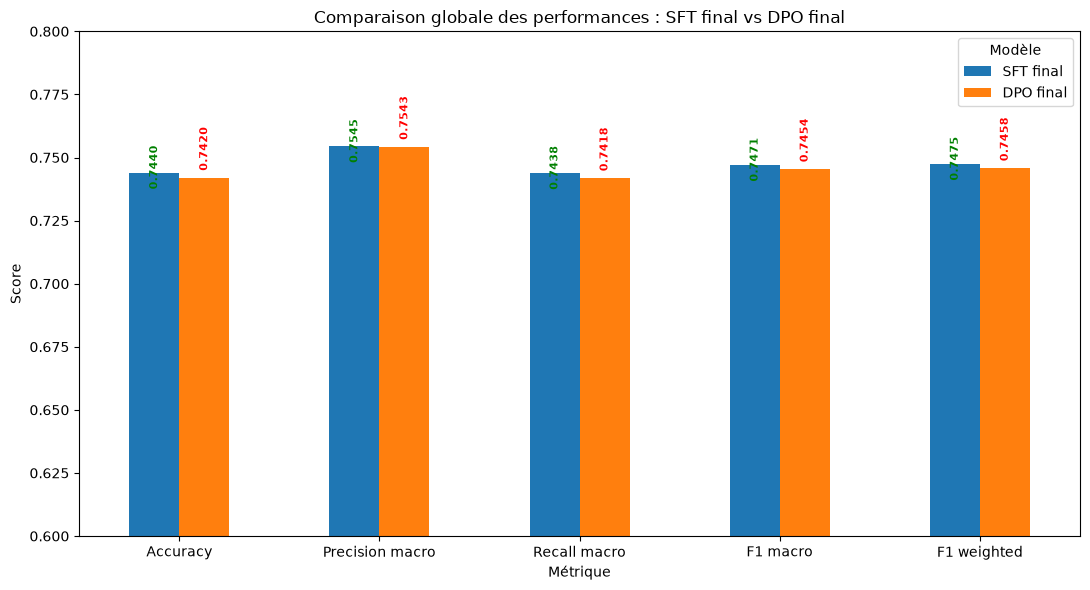

In [68]:
# Visualise les métriques globales SFT final et DPO final.

global_metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]

global_metrics_df = (
    metrics_comparison_df
    .set_index("metric")
    .loc[global_metrics, ["SFT final", "DPO final"]]
)

global_metrics_df.index = [
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro",
    "F1 weighted"
]

ax = global_metrics_df.plot.bar(figsize=(11, 6))

ax.set(
    ylim=(0.60, 0.80),
    xlabel="Métrique",
    ylabel="Score",
    title="Comparaison globale des performances : SFT final vs DPO final"
)

ax.tick_params(axis="x", rotation=0)
ax.legend(title="Modèle")


# Colore les valeurs : meilleur en vert, moins bon en rouge, égalité en noir.

values = global_metrics_df[["SFT final", "DPO final"]].to_numpy()

for model_index, container in enumerate(ax.containers):
    offset = -12 if model_index == 0 else 5

    for metric_index, bar in enumerate(container):
        value = bar.get_height()
        other = values[metric_index, 1 - model_index]

        if np.isclose(value, other):
            color = "black"
        elif value > other:
            color = "green"
        else:
            color = "red"

        ax.annotate(
            f"{value:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()

figure = ax.get_figure()

figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_global_metrics_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [70]:
# Construit les métriques P1/P2/P3 pour le graphique.

rows = []

for priority in (1, 2, 3):
    for metric in ("precision", "recall", "f1"):
        key = f"{metric}_p{priority}"

        rows.append({
            "label": f"P{priority} {metric.title()}",
            "SFT final": sft_comparison[key],
            "DPO final": dpo_comparison[key]
        })

class_metrics_df = pd.DataFrame(rows)

display(class_metrics_df.round(6))

,label,SFT final,DPO final
0,P1 Precision,0.910345,0.916667
1,P1 Recall,0.785714,0.785714
2,P1 F1,0.843450,0.846154
3,P2 Precision,0.651934,0.645503
4,P2 Recall,0.710843,0.734940
5,P2 F1,0.680115,0.687324
6,P3 Precision,0.701149,0.700599
7,P3 Recall,0.734940,0.704819
8,P3 F1,0.717647,0.702703


In [ ]:
# Visualise les performances par priorité.

plot_df = class_metrics_df.set_index("label")[["SFT v2", "DPO v2"]]

ax = plot_df.plot.bar(figsize=(13, 6))

ax.set(
    ylim=(0.55, 0.84),
    xlabel="Priorité et métrique",
    ylabel="Score",
    title="Comparaison SFT v2 / DPO v2 : précision, rappel et F1 par priorité"
)

ax.tick_params(axis="x", rotation=45)
ax.legend(title="Modèle")


# Colore les valeurs : meilleur en vert, moins bon en rouge, égalité en noir.

values = plot_df.to_numpy()

for model_index, container in enumerate(ax.containers):
    offset = -12 if model_index == 0 else 5

    for metric_index, bar in enumerate(container):
        value = bar.get_height()
        other = values[metric_index, 1 - model_index]

        if np.isclose(value, other):
            color = "black"
        elif value > other:
            color = "green"
        else:
            color = "red"

        ax.annotate(
            f"{value:.6f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()

figure = ax.get_figure()

figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_class_metrics_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

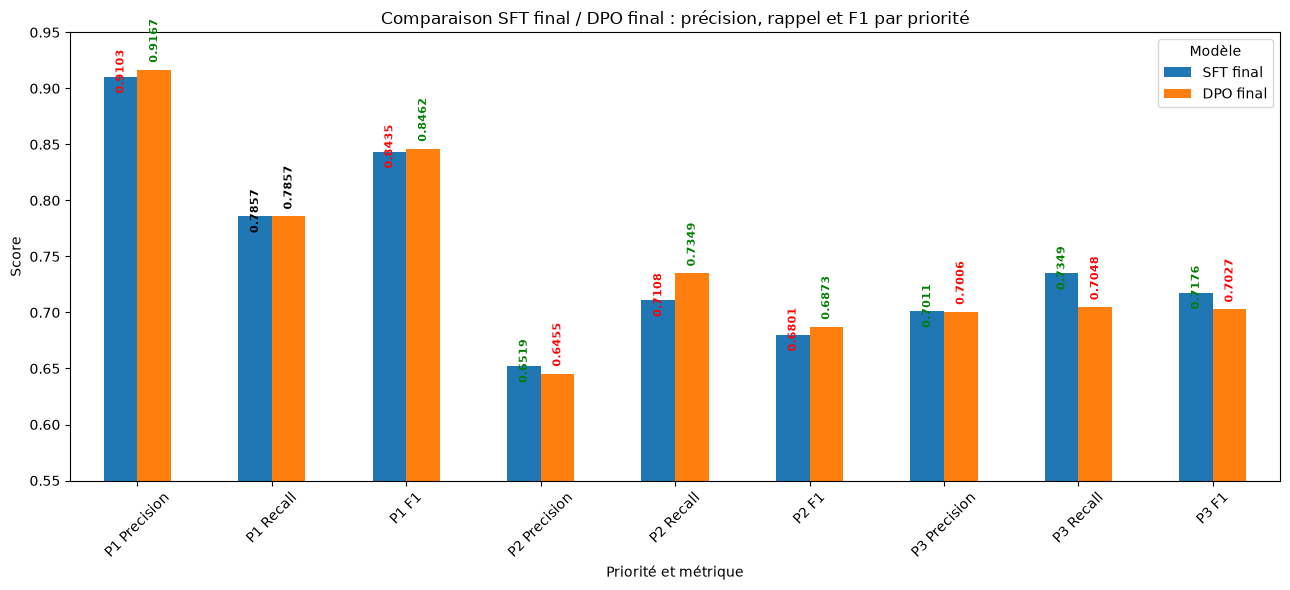

In [71]:
# Visualise les performances par priorité.

plot_df = class_metrics_df.set_index("label")[
    ["SFT final", "DPO final"]
]

ax = plot_df.plot.bar(figsize=(13, 6))

ax.set(
    ylim=(0.55, 0.95),
    xlabel="Priorité et métrique",
    ylabel="Score",
    title="Comparaison SFT final / DPO final : précision, rappel et F1 par priorité"
)

ax.tick_params(axis="x", rotation=45)
ax.legend(title="Modèle")


# Colore les valeurs : meilleur en vert, moins bon en rouge, égalité en noir.

values = plot_df.to_numpy()

for model_index, container in enumerate(ax.containers):
    offset = -12 if model_index == 0 else 5

    for metric_index, bar in enumerate(container):
        value = bar.get_height()
        other = values[metric_index, 1 - model_index]

        if np.isclose(value, other):
            color = "black"
        elif value > other:
            color = "green"
        else:
            color = "red"

        ax.annotate(
            f"{value:.4f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
            color=color,
            fontweight="bold"
        )

plt.tight_layout()

figure = ax.get_figure()

figure.savefig(
    RUN_METRIC_DIR / "sft_dpo_class_metrics_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [72]:
# Recalcule le sous-triage depuis les prédictions sauvegardées.

sft_undertriage, sft_undertriage_details = undertriage_report(
    sft_results_df,
    "SFT final"
)

dpo_undertriage, dpo_undertriage_details = undertriage_report(
    dpo_results_df,
    "DPO final"
)

print("✓ Sous-triage SFT / DPO recalculé")

✓ Sous-triage SFT / DPO recalculé


In [73]:
# Compare le sous-triage SFT final et DPO final.
# Delta négatif = amélioration, delta positif = dégradation.

undertriage_comparison = sft_undertriage[
    ["transition", "count", "rate_pct"]
].merge(
    dpo_undertriage[["transition", "count", "rate_pct"]],
    on="transition",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

undertriage_comparison["count_delta"] = (
    undertriage_comparison["count_dpo"]
    - undertriage_comparison["count_sft"]
)

undertriage_comparison["rate_delta"] = (
    undertriage_comparison["rate_pct_dpo"]
    - undertriage_comparison["rate_pct_sft"]
).round(2)


# Affichage lisible pour l'analyse.

undertriage_display = undertriage_comparison.rename(columns={
    "transition": "Sous-triage",
    "count_sft": "Cas SFT",
    "rate_pct_sft": "Taux SFT (%)",
    "count_dpo": "Cas DPO",
    "rate_pct_dpo": "Taux DPO (%)",
    "count_delta": "Δ cas",
    "rate_delta": "Δ taux (pts)"
})

print("=== SOUS-TRIAGE : SFT final vs DPO final ===")
print("Δ négatif = réduction du sous-triage | Δ positif = augmentation")

display(
    undertriage_display.style.format({
        "Taux SFT (%)": "{:.2f}%",
        "Taux DPO (%)": "{:.2f}%",
        "Δ taux (pts)": "{:+.2f}"
    })
)


# Sauvegarde les valeurs techniques.

undertriage_comparison.to_csv(
    RUN_METRIC_DIR / "sft_dpo_undertriage_comparison.csv",
    index=False,
    encoding="utf-8"
)

=== SOUS-TRIAGE : SFT final vs DPO final ===
Δ négatif = réduction du sous-triage | Δ positif = augmentation


,Sous-triage,Cas SFT,Taux SFT (%),Cas DPO,Taux DPO (%),Δ cas,Δ taux (pts)
0,P1 → P2,20,11.90%,19,11.31%,-1,-0.60
1,P1 → P3,16,9.52%,17,10.12%,1,+0.60
2,P2 → P3,36,21.69%,33,19.88%,-3,-1.81


In [ ]:


# Compare les succès SFT et DPO avec le test exact de McNemar.

paired = sft_results_df[
    ["id", "expected", "predicted"]
].merge(
    dpo_results_df[["id", "expected", "predicted"]],
    on="id",
    suffixes=("_sft", "_dpo"),
    validate="one_to_one"
)

# Vérifie que la comparaison porte exactement sur le test gelé.
assert len(paired) == len(test_df)
assert paired["id"].is_unique
assert (paired["expected_sft"] == paired["expected_dpo"]).all()

paired["expected"] = paired["expected_sft"]

paired["sft_correct"] = (
    paired["expected"] == paired["predicted_sft"]
)

paired["dpo_correct"] = (
    paired["expected"] == paired["predicted_dpo"]
)

sft_only = int(
    (paired["sft_correct"] & ~paired["dpo_correct"]).sum()
)

dpo_only = int(
    (~paired["sft_correct"] & paired["dpo_correct"]).sum()
)

both_correct = int(
    (paired["sft_correct"] & paired["dpo_correct"]).sum()
)

both_wrong = int(
    (~paired["sft_correct"] & ~paired["dpo_correct"]).sum()
)

discordant = sft_only + dpo_only

mcnemar_pvalue = (
    binomtest(
        dpo_only,
        discordant,
        p=0.5
    ).pvalue
    if discordant
    else 1.0
)


# Tableau 1 : transitions de classes SFT → DPO.

transition_table = pd.crosstab(
    paired["predicted_sft"],
    paired["predicted_dpo"],
    rownames=["Prédiction SFT"],
    colnames=["Prédiction DPO"],
    dropna=False
)

transition_table.index = [
    f"P{x}" for x in transition_table.index
]

transition_table.columns = [
    f"P{x}" for x in transition_table.columns
]

print("=== TRANSITIONS DE PRÉDICTIONS : SFT final → DPO final ===")
display(transition_table)


# Tableau 2 : évolution du statut correct / incorrect.

agreement_df = pd.DataFrame({
    "Résultat": [
        "Correct avec les deux modèles",
        "Incorrect avec les deux modèles",
        "Correct SFT → incorrect DPO",
        "Incorrect SFT → correct DPO"
    ],
    "Cas": [
        both_correct,
        both_wrong,
        sft_only,
        dpo_only
    ]
})

agreement_df["Part (%)"] = (
    agreement_df["Cas"] / len(paired) * 100
)

print("=== COMPARAISON DES SUCCÈS SFT / DPO ===")

display(
    agreement_df.style.format({
        "Part (%)": "{:.2f}%"
    })
)


# Tableau 3 : test exact de McNemar.

mcnemar_df = pd.DataFrame({
    "Indicateur": [
        "Cas testés",
        "SFT seul correct",
        "DPO seul correct",
        "Paires discordantes",
        "McNemar p-value"
    ],
    "Valeur": [
        len(paired),
        sft_only,
        dpo_only,
        discordant,
        mcnemar_pvalue
    ]
})

print("=== TEST EXACT DE McNEMAR ===")
display(mcnemar_df)


# Sauvegarde les résultats.

transition_table.to_csv(
    RUN_METRIC_DIR / "sft_dpo_prediction_transitions.csv",
    encoding="utf-8"
)

mcnemar_results = {
    "test_rows": len(paired),
    "both_correct": both_correct,
    "both_wrong": both_wrong,
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "discordant": discordant,
    "p_value": float(mcnemar_pvalue)
}

(RUN_METRIC_DIR / "sft_dpo_mcnemar.json").write_text(
    json.dumps(mcnemar_results, indent=2),
    encoding="utf-8"
)

print("✓ Comparaison appariée SFT / DPO sauvegardée")

=== TRANSITIONS DE PRÉDICTIONS : SFT final → DPO final ===


,P1,P2,P3
P1,142,3,0
P2,2,174,5
P3,0,12,162


=== COMPARAISON DES SUCCÈS SFT / DPO ===


,Résultat,Cas,Part (%)
0,Correct avec les deux modèles,361,72.20%
1,Incorrect avec les deux modèles,118,23.60%
2,Correct SFT → incorrect DPO,11,2.20%
3,Incorrect SFT → correct DPO,10,2.00%


=== TEST EXACT DE McNEMAR ===


,Indicateur,Valeur
0,Cas testés,500.0
1,SFT seul correct,11.0
2,DPO seul correct,10.0
3,Paires discordantes,21.0
4,McNemar p-value,1.0


✓ Comparaison appariée SFT / DPO sauvegardée


In [78]:
# Résume factuellement l'effet du DPO sur le test commun.

macro_delta = (
    dpo_comparison["f1_macro"]
    - sft_comparison["f1_macro"]
)

p1_recall_delta = (
    dpo_comparison["recall_p1"]
    - sft_comparison["recall_p1"]
)

if macro_delta > 0 and p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1 et le rappel P1 "
        "sur le test commun."
    )
elif p1_recall_delta > 0:
    conclusion = (
        "Le DPO augmente le rappel P1, tandis que le macro-F1 "
        "n'augmente pas."
    )
elif macro_delta > 0:
    conclusion = (
        "Le DPO augmente le macro-F1, tandis que le rappel P1 "
        "n'augmente pas."
    )
else:
    conclusion = (
        "Le DPO n'augmente ni le macro-F1 ni le rappel P1 "
        "sur le test commun."
    )

comparison_payload = {
    "macro_f1_delta": float(macro_delta),
    "p1_recall_delta": float(p1_recall_delta),
    "mcnemar_pvalue": float(mcnemar_pvalue),
    "sft_only_correct": sft_only,
    "dpo_only_correct": dpo_only,
    "conclusion": conclusion
}

(RUN_METRIC_DIR / "sft_dpo_conclusion.json").write_text(
    json.dumps(
        comparison_payload,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

display(pd.DataFrame([comparison_payload]))

print(conclusion)
print(
    "Conclusion à compléter par la matrice de confusion, "
    "le sous-triage et l'analyse des erreurs."
)
print("✓ Comparaison SFT / DPO terminée")

,macro_f1_delta,p1_recall_delta,mcnemar_pvalue,sft_only_correct,dpo_only_correct,conclusion
0,-0.001677,0.0,1.0,11,10,Le DPO n'augmente ni le macro-F1 ni le rappel ...


Le DPO n'augmente ni le macro-F1 ni le rappel P1 sur le test commun.
Conclusion à compléter par la matrice de confusion, le sous-triage et l'analyse des erreurs.
✓ Comparaison SFT / DPO terminée


## 12. Conclusion et manifeste

Je termine en sauvegardant les versions, empreintes, chemins et métriques. Ce manifeste permet de relier un résultat aux données, aux adaptateurs et au groupe W&B qui l’ont produit.


In [ ]:


# Construit le manifest final uniquement avec les variables réellement disponibles.

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),

    # Run
    "run": {
        "stamp": RUN_STAMP,
        "group": RUN_GROUP,
        "wandb_enabled": USE_WANDB,
        "wandb_project": WANDB_PROJECT if USE_WANDB else None,
        "seed": CONFIG.seed
    },

    # Configuration complète
    "configuration": asdict(CONFIG),

    # Environnement
    "environment": {
        "python": sys.version,
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
        "gpu_count": (
            torch.cuda.device_count()
            if torch.cuda.is_available()
            else 0
        ),
        "bf16_supported": (
            torch.cuda.is_bf16_supported()
            if torch.cuda.is_available()
            else False
        )
    },

    # Provenance des modèles
    "models": {
        "base_model": "unsloth/Qwen3-1.7B-unsloth-bnb-4bit",
        "sft_source_stamp": SFT_SOURCE_STAMP,
        "sft_source_checkpoint": SFT_SOURCE_CHECKPOINT,
        "dpo_adapter": str(DPO_MODEL_PATH)
    },

    # Jeu de test final
    "test": {
        "rows": len(test_df),
        "sft_prediction_rows": len(sft_results_df),
        "dpo_prediction_rows": len(dpo_results_df),
        "same_ids": (
            set(sft_results_df["id"])
            == set(dpo_results_df["id"])
            == set(test_df["id"])
        )
    },

    # Résultats SFT
    "sft_results": {
        "global_metrics": sft_metrics,

        "per_class_metrics": (
            sft_class_metrics.to_dict("records")
        ),

        "confusion_matrix": (
            np.asarray(sft_confusion).tolist()
        ),

        "undertriage": (
            sft_undertriage.to_dict("records")
        ),

        "undertriage_details_rows": len(
            sft_undertriage_details
        )
    },

    # Résultats DPO
    "dpo_results": {
        "global_metrics": dpo_metrics,

        "per_class_metrics": (
            dpo_class_metrics.to_dict("records")
        ),

        "confusion_matrix": (
            np.asarray(dpo_confusion).tolist()
        ),

        "undertriage": (
            dpo_undertriage.to_dict("records")
        ),

        "undertriage_details_rows": len(
            dpo_undertriage_details
        )
    },

    # Comparaison des métriques globales
    "global_comparison": (
        metrics_comparison_df.to_dict("records")
    ),

    # Comparaison par priorité
    "class_comparison": (
        class_metrics_df.to_dict("records")
    ),

    # Comparaison du sous-triage
    "undertriage_comparison": (
        undertriage_comparison.to_dict("records")
    ),

    # Comparaison appariée SFT / DPO
    "paired_comparison": {
        "test_rows": len(paired),

        "both_correct": both_correct,
        "both_wrong": both_wrong,

        "sft_only_correct": sft_only,
        "dpo_only_correct": dpo_only,

        "discordant": discordant,

        "mcnemar_exact": {
            "method": "exact_binomial",
            "alternative": "two-sided",
            "p_value": float(mcnemar_pvalue)
        },

        "prediction_transitions": (
            transition_table
            .reset_index()
            .to_dict("records")
        )
    },

    # Résultat McNemar sauvegardé
    "mcnemar": mcnemar_results,

    # Artefacts de l'évaluation finale
    "artifacts": {
        "sft_metrics": str(
            RUN_METRIC_DIR / "sft_metrics.json"
        ),

        "dpo_metrics": str(
            RUN_METRIC_DIR / "dpo_metrics.json"
        ),

        "sft_predictions": str(
            RUN_METRIC_DIR / "sft_predictions.jsonl"
        ),

        "dpo_predictions": str(
            RUN_METRIC_DIR / "dpo_predictions.jsonl"
        ),

        "global_metrics_figure": str(
            RUN_METRIC_DIR
            / "sft_dpo_global_metrics_comparison.png"
        ),

        "class_metrics_figure": str(
            RUN_METRIC_DIR
            / "sft_dpo_class_metrics_comparison.png"
        ),

        "undertriage_comparison": str(
            RUN_METRIC_DIR
            / "sft_dpo_undertriage_comparison.csv"
        ),

        "prediction_transitions": str(
            RUN_METRIC_DIR
            / "sft_dpo_prediction_transitions.csv"
        ),

        "mcnemar": str(
            RUN_METRIC_DIR
            / "sft_dpo_mcnemar.json"
        )
    }
}


# Sauvegarde.

MANIFEST_PATH = RUN_METRIC_DIR / "experiment_manifest.json"

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        ensure_ascii=False,
        indent=2,
        default=str
    ),
    encoding="utf-8"
)


# Contrôles finaux.

assert manifest["test"]["rows"] == len(test_df)
assert manifest["test"]["same_ids"]
assert manifest["paired_comparison"]["test_rows"] == len(test_df)


# Résumé.

print("=== MANIFEST EXPÉRIMENTAL FINAL ===")
print(f"Run             : {RUN_STAMP}")
print(f"Groupe W&B      : {RUN_GROUP}")
print(f"Test            : {len(test_df):,} cas")
print(f"SFT predictions : {len(sft_results_df):,}")
print(f"DPO predictions : {len(dpo_results_df):,}")
print(f"Discordances    : {discordant}")
print(f"McNemar p-value : {mcnemar_pvalue:.6f}")
print(f"Manifest        : {MANIFEST_PATH}")
print("✓ Manifest SFT / DPO sauvegardé")

=== MANIFEST EXPÉRIMENTAL FINAL ===
Run             : 20261007-003909
Groupe W&B      : qwen3-triage-20261007-003909
Test            : 500 cas
SFT predictions : 500
DPO predictions : 500
Discordances    : 21
McNemar p-value : 1.000000
Manifest        : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\artifacts\finetuning_sft_dpo\metrics\20261007-003909\experiment_manifest.json
✓ Manifest SFT / DPO sauvegardé


Références techniques : [TRL SFTTrainer](https://huggingface.co/docs/trl/main/en/sft_trainer), [TRL DPOTrainer](https://huggingface.co/docs/trl/main/en/dpo_trainer), [W&B × Transformers](https://docs.wandb.ai/models/integrations/huggingface), [quantification bitsandbytes](https://huggingface.co/docs/transformers/main/en/quantization/bitsandbytes).
